# Realism-Matched Synthetic Channel — H3 gap, H4 inverted-U, silent-wrong

This notebook is a **runnable, annotated demo** of the experiment that re-establishes
the closure-certified text→logic module's three mechanism results under a *simulated
reader channel calibrated to a real-text frontier pilot*. It is the original
`method.py` split into cells with explanations between each section — the algorithms
are unchanged.

**What it does (zero LLM spend, pure CPU):** a single ordinal reader knob S1–S5
*samples* each edge's error-type directly from a real-text–calibrated distribution, so
per-edge **recall = 1 − P(unsound)** becomes an *output* (fixing iter-1's dead knob).
On consistent-by-construction qualitative constraint networks (QCNs) it then measures:

- **H3** — iterated path-consistency (FULL) beats single-pass intersection (NAIVE),
  *at each fixed recall slice*: a tie at hop length 2, growing with hop length and with
  cyclomatic (redundancy) number.
- **H4** — redundancy gives a recall-dependent **inverted-U** in Mode-A resolution; the
  peak shifts outward with recall, and joint soundness J(E) > rᴱ under cross-edge ρ>0.
- **silent-wrong vs recall** — monotone-decreasing, bounded above by the per-network
  read-soundness bound 1−J(E) (rigorous), reported separately from the **zero-FP
  theorem** (all-sound contributing edges ⇒ gold in the output with probability 1).

**Realism** is verified three ways: per-edge error-type total variation (TV) in the
apples-to-apples projected point ladder, cross-edge ρ calibration, and topology match to
the NarrativeTime gold graphs.

> **Demo scale.** The config cell starts at a small *mini* scale (N=30, B=300) — large
> enough that every mechanism verdict (H3, H4, realism, silent-wrong, zero-FP) reproduces,
> yet the whole notebook runs in a few seconds. The original full-scale values
> (N=600, B=2000) that the paper used are given in comments — bump the config and re-run
> for a full reproduction (≈140 s on a multi-core box).


In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *a])

# This experiment only uses numpy/scipy/matplotlib — all pre-installed on Colab.
# On Colab: skip (installing would corrupt the pre-loaded C extensions).
# Locally: install at Colab's exact versions so the env matches Colab.
if "google.colab" not in sys.modules:
    _pip("numpy==2.0.2", "scipy==1.16.3", "matplotlib==3.10.0")


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


## Imports

The original import block from `method.py`, plus `IPython.display` for showing the saved figures inline. `matplotlib` is forced to the non-interactive `Agg` backend exactly as in the original (figures are written to `figures/` and displayed at the end).

In [2]:
from __future__ import annotations

import argparse
import gc
import json
import math
import os
import resource
import sys
import time
import zlib
from collections import deque, Counter
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path
import multiprocessing as mp

import numpy as np
from scipy.stats import norm, spearmanr
from scipy.integrate import quad
from scipy.optimize import brentq, nnls

try:
    from scipy.stats import page_trend_test as _scipy_page
    _HAS_SCIPY_PAGE = True
except Exception:  # pragma: no cover
    _HAS_SCIPY_PAGE = False

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# --- notebook additions ---
from IPython.display import Image, display
# numpy 2.0 compatibility shims (harmless if already present)
if not hasattr(np, "alltrue"): np.alltrue = np.all
if not hasattr(np, "product"): np.product = np.prod

## Load the calibration data

The original script reads three local files: the iter-1 real-text **frontier table** (the calibration target), the **NarrativeTime point gold graphs** (topology target), and a **synthetic QCN preview** (composition-table cross-check). For this demo they are bundled into a single `mini_demo_data.json` hosted on GitHub, with a local fallback so the notebook runs both in Colab and locally.

*The topology bundle holds the 6 smallest gold graphs so the BFS realism check runs instantly; the frontier table and QCN examples are complete.*

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-2/experiment-2/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("loaded keys:", list(data.keys()))
print("frontier_table rows:", len(data["frontier_table"]),
      "| arms:", sorted(set(r["arm"] for r in data["frontier_table"])))
print("topology gold graphs:", len(data["topology"]["docs"]))
print("qcn cross-check examples:", len(data["qcn_examples"]))

loaded keys: ['_about', 'frontier_table', 'topology', 'qcn_examples']
frontier_table rows: 10 | arms: ['TBDense_dense', 'TDDMan_noncirc']
topology gold graphs: 6
qcn cross-check examples: 10


## Config — all tunable parameters

Every knob lives here. The defaults are a small **mini** scale — enough that every result
reproduces (all PASS) while running in seconds. The original `method.py` exposed four
scales via `make_config`; their values are kept in comments. Bump these (especially `N`
and `B`) toward the `full` values for a paper-grade run.

- `RECALL`, `RHO`, `GATE` — channel operating points (per-edge recall, cross-edge soundness
  correlation, confidence-gate on/off).
- `K` — redundancy (parallel two-hop paths) for H4.
- `HOP`, `CYCLO`, `CYCLO_L` — hop length / interior chords / fixed chain length for H3.
- `H3_SLICES` — the fixed per-edge recall slices at which the H3 gap is reported.
- `N` — networks simulated per cell; `B` — bootstrap resamples.
- `N_MC_CALIB`, `N_SIM_RHO` — Monte-Carlo sizes for the realism calibration checks.


In [5]:
from pathlib import Path
import time, math, os, resource

# ---- where figures / logs go (local dir; works on Colab too) ----
WORKSPACE = Path(".")
FIG_DIR = WORKSPACE / "figures"
LOG_DIR = WORKSPACE / "logs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
_LOG_FH = open(LOG_DIR / "run.log", "a")

def log(msg: str) -> None:
    line = f"[{time.strftime('%H:%M:%S')}] {msg}"
    print(line, flush=True)
    try:
        _LOG_FH.write(line + "\n"); _LOG_FH.flush()
    except Exception:
        pass

# ---- constants (verbatim from method.py) ----
SEED_BASE = 20260617
ALPHA = 0.05
GATE_DROP_FRACTION = 0.20
TV_THRESHOLD = 0.10
RHO_THRESHOLD = 0.10
TOPO_THRESHOLD = 0.15

# ============================ TUNABLE PARAMETERS ============================ #
# Demo default = "mini" scale: small but enough that every mechanism verdict
# (H3, H4, realism, silent-wrong, zero-FP) reproduces; runs in ~7 s. The
# original make_config scales:
#   smoke (absolute min, ~5 s, H3/H4 noisy):
#          RECALL=[0.5,0.9]  RHO=[0.0,0.5]  GATE=["off"]
#          K=[1,2,4,6]  HOP=[2,3,4]  CYCLO=[0,1]  CYCLO_L=4
#          H3_SLICES=[0.9,1.0]  N=20  B=200
#   test : RECALL=[.50,.625,.78,.90,.95]  RHO=[0.0,0.5,0.7]  GATE=["off","on"]
#          K=[1,2,3,4,5,6,8,10,12,16]  HOP=[2,3,4,5,6]  CYCLO=[0,1,2,3]  CYCLO_L=6
#          H3_SLICES=auto  N=150  B=1000   (~36 s)
#   full : RECALL=[.50,.625,.78,.90,.95]  RHO=[0.0,0.5,0.7]  GATE=["off","on"]
#          K=[1,2,3,4,5,6,7,8,10,12,14,16]  HOP=[2,3,4,5,6]  CYCLO=[0,1,2,3]  CYCLO_L=6
#          H3_SLICES=auto  N=600  B=2000   (~140 s, the paper's grid)
RECALL    = [0.5, 0.625, 0.9]   # full: [0.50, 0.625, 0.78, 0.90, 0.95]
RHO       = [0.0, 0.5]          # full: [0.0, 0.5, 0.7]
GATE      = ["off", "on"]       # full: ["off", "on"]
K         = [1, 2, 3, 4, 6, 8]  # full: [1,2,3,4,5,6,7,8,10,12,14,16]
HOP       = [2, 3, 4]           # full: [2, 3, 4, 5, 6]
CYCLO     = [0, 1, 2]           # full: [0, 1, 2, 3]
CYCLO_L   = 5                   # full: 6
H3_SLICES = [0.625, 0.9, 1.0]   # full: sorted set of knob recalls + {0.90,0.95,1.00}
N         = 30                  # full: 600   (networks per cell)
B         = 300                 # full: 2000  (bootstrap resamples)

N_MC_CALIB = 8000           # full: 40000 (calibration-unit-test MC edges)
N_SIM_RHO  = 20000          # full: 60000 (rho-block MC samples)
N_WORKERS  = 1              # serial in-notebook (avoids spawn/multiprocessing issues)
RUN_ALLEN  = True           # run the secondary Allen-13 same-algebra arm

cfg = dict(RECALL=RECALL, RHO=RHO, GATE=GATE, K=K, HOP=HOP, CYCLO=CYCLO,
           CYCLO_L=CYCLO_L, H3_SLICES=H3_SLICES, N=N, B=B)
print("cfg:", cfg)

cfg: {'RECALL': [0.5, 0.625, 0.9], 'RHO': [0.0, 0.5], 'GATE': ['off', 'on'], 'K': [1, 2, 3, 4, 6, 8], 'HOP': [2, 3, 4], 'CYCLO': [0, 1, 2], 'CYCLO_L': 5, 'H3_SLICES': [0.625, 0.9, 1.0], 'N': 30, 'B': 300}


## 1. Relation algebra — convex point algebra

The primary algebra is the **convex point algebra** over base relations `<`, `=`, `>`
(bit-encoded). `COMP`/`CONV` are the composition and converse tables, built from the base
tables and **self-verified** (associativity over 2000 random convex triples, identity,
converse involution, and closure of the convex fragment). Path-consistency is *complete*
for this algebra, so the exact answer is recoverable.

In [6]:
LT, EQ, GT, U, EMPTY = 1, 2, 4, 7, 0
BASE_BITS = (LT, EQ, GT)
CONVEX = (LT, EQ, GT, LT | EQ, EQ | GT, U)          # {<,=,>,<=,>=,?}
NONCONVEX = LT | GT                                  # 5 == NOT-EQUAL (forbidden read)
REL_NAME = {0: "EMPTY", 1: "<", 2: "=", 4: ">", 3: "<=", 6: ">=", 7: "?", 5: "<>"}

BASE_COMP = {
    (LT, LT): LT, (LT, EQ): LT, (LT, GT): U,
    (EQ, LT): LT, (EQ, EQ): EQ, (EQ, GT): GT,
    (GT, LT): U,  (GT, EQ): GT, (GT, GT): GT,
}
CONV_BASE = {LT: GT, EQ: EQ, GT: LT}


def _build_tables():
    comp = [[0] * 8 for _ in range(8)]
    conv = [0] * 8
    for R in range(8):
        m = 0
        for a in BASE_BITS:
            if R & a:
                m |= CONV_BASE[a]
        conv[R] = m
        for S in range(8):
            mm = 0
            for a in BASE_BITS:
                if R & a:
                    for b in BASE_BITS:
                        if S & b:
                            mm |= BASE_COMP[(a, b)]
            comp[R][S] = mm
    return comp, conv


COMP, CONV = _build_tables()


def popcount(x: int) -> int:
    return bin(x).count("1")


def self_verify_point_algebra() -> None:
    assert COMP[LT][LT] == LT and COMP[LT][EQ] == LT and COMP[LT][GT] == U
    assert COMP[EQ][GT] == GT and COMP[GT][LT] == U and COMP[GT][GT] == GT
    assert CONV[LT] == GT and CONV[GT] == LT and CONV[EQ] == EQ
    assert CONV[LT | EQ] == EQ | GT
    assert (LT | EQ) & (EQ | GT) == EQ
    for R in CONVEX:
        assert COMP[EQ][R] == R and COMP[R][EQ] == R
    for R in CONVEX:
        for S in CONVEX:
            assert COMP[R][S] != NONCONVEX
            assert (R & S) != NONCONVEX
    rng = np.random.default_rng(0)
    for _ in range(2000):
        a, b, c = (int(rng.choice(CONVEX)) for _ in range(3))
        assert COMP[COMP[a][b]][c] == COMP[a][COMP[b][c]]
    log("Stage 0 point-algebra self-verify: PASS")

## 2. QCN generators (consistent by construction)

Networks are realized from an actual timeline, so the gold query relation is exact by
construction. **Family R** (for H4) builds `K` parallel two-hop paths A→mₖ→B — pure
redundancy. **Family H** (for H3) builds a length-`L` chain plus `C` interior chords; its
*cyclomatic number* counts independent alternative routes.

In [7]:
class Net:
    __slots__ = ("n", "edges", "gold", "query", "gold_query")

    def __init__(self, n, edges, gold, query, gold_query):
        self.n = n
        self.edges = edges
        self.gold = gold
        self.query = query
        self.gold_query = gold_query


def _base_from_times(ta, tb):
    if ta < tb:
        return LT
    if ta > tb:
        return GT
    return EQ


def gen_family_R(K: int, rng: np.random.Generator) -> Net:
    """REDUNDANCY family (H4): K parallel length-2 paths i -> m_k -> j."""
    i, j = 0, 1
    t = {i: 0.0, j: 10.0}
    edges = []
    gold = {}
    for k in range(K):
        m = 2 + k
        t[m] = float(rng.uniform(1.0, 9.0))
        edges.append((i, m))
        edges.append((m, j))
    for (a, b) in edges:
        gold[(a, b)] = _base_from_times(t[a], t[b])
    query = (i, j)
    gold_query = _base_from_times(t[i], t[j])     # == LT
    gold[query] = gold_query
    return Net(2 + K, edges, gold, query, gold_query)


def gen_family_H(L: int, C: int, rng: np.random.Generator):
    """HOP/CYCLOMATIC family (H3): chain of L edges (L+1 nodes) + C interior chords."""
    i, j = 0, L
    t = {node: float(node) for node in range(L + 1)}
    edges = [(n_, n_ + 1) for n_ in range(L)]
    interior = list(range(1, L))
    cand = [(a, b) for ai, a in enumerate(interior) for b in interior[ai + 1:]
            if b - a >= 2]
    rng.shuffle(cand)
    added = 0
    for (a, b) in cand:
        if added >= C:
            break
        if (a, b) in edges or (b, a) in edges:
            continue
        edges.append((a, b))
        added += 1
    gold = {}
    for (a, b) in edges:
        gold[(a, b)] = _base_from_times(t[a], t[b])
    query = (i, j)
    gold_query = _base_from_times(t[i], t[j])     # == LT
    gold[query] = gold_query
    cyclo = len(edges) - (L + 1) + 1
    return Net(L + 1, edges, gold, query, gold_query), cyclo

## 3. The calibrated simulated reader channel (the core fix)

A **single ordinal knob** drives the channel. Soundness is an equicorrelated-latent
Bernoulli with marginal = `recall` and pairwise correlation ≈ `rho`. Sound edges draw a
breadth category (singleton / pair / universal) from `shape3`; unsound edges emit a
gold-*excluding* convex set. Because the per-edge error-type distribution is *sampled
directly* from the calibrated real distribution, **recall is an output**, not an
independent input — so sweeping the knob genuinely trades recall for bite.

In [8]:
PT_SINGLETON, PT_PAIR, PT_UNIV, PT_UNSOUND = 0, 1, 2, 3
PT_CAT_NAME = {0: "singleton", 1: "pair", 2: "universal", 3: "unsound"}

# Convex gold-EXCLUDING (unsound) options per gold relation (never the non-convex 5).
_UNSOUND = {
    LT: [EQ, GT, EQ | GT],
    EQ: [LT, GT],
    GT: [LT, EQ, LT | EQ],
}


def categorize_point(s: int, g: int) -> int:
    """Bin a point-algebra emitted set s (gold base relation g) into one of the
    four NATIVE point error-type categories."""
    if not (s & g):
        return PT_UNSOUND
    if popcount(s) == 1:
        return PT_SINGLETON
    if s == U:
        return PT_UNIV
    return PT_PAIR


def _emit_point_sound(g: int, cat: int, rng: np.random.Generator) -> int:
    if cat == PT_SINGLETON:
        return g
    if cat == PT_UNIV:
        return U
    # PT_PAIR : the sound 2-set containing g
    if g == LT:
        return LT | EQ
    if g == GT:
        return EQ | GT
    return (LT | EQ) if rng.random() < 0.5 else (EQ | GT)   # g == EQ


def _emit_point_unsound(g: int, want_pair: bool, rng: np.random.Generator) -> int:
    opts = _UNSOUND[g]
    if want_pair:
        pairs = [o for o in opts if popcount(o) == 2]
        if pairs:
            return int(rng.choice(pairs))
    singles = [o for o in opts if popcount(o) == 1]
    return int(rng.choice(singles if singles else opts))


class ReadResult:
    __slots__ = ("rel", "sound", "conf", "edges", "bite_lost", "kept")

    def __init__(self, rel, sound, conf, edges, bite_lost, kept):
        self.rel = rel
        self.sound = sound
        self.conf = conf
        self.edges = edges
        self.bite_lost = bite_lost
        self.kept = kept


def read_network_point(net: Net, recall: float, shape3, rho: float,
                       rng: np.random.Generator, gate: bool, gate_drop: float) -> ReadResult:
    """CALIBRATED point channel.

    recall  : marginal per-edge soundness probability (= 1 - P(unsound)).
    shape3  : (w_singleton, w_pair, w_univ) breadth split *among SOUND edges*.
    rho     : cross-edge equicorrelated soundness correlation (within-network).

    Soundness is an equicorrelated-latent Bernoulli (marginal == recall, pairwise
    corr ~ rho).  Sound edges draw a breadth category from shape3 and realize it;
    unsound edges emit a gold-EXCLUDING convex set whose singleton/pair split
    mirrors shape3.  Per-edge recall is now an OUTPUT of the (knob) inputs, so
    sweeping the knob genuinely trades recall for bite.
    """
    qn = norm.ppf(min(max(recall, 1e-9), 1.0 - 1e-9))
    u_latent = float(rng.standard_normal())
    a = math.sqrt(rho)
    b = math.sqrt(1.0 - rho)
    ws, wp, wu = shape3
    tot = ws + wp + wu
    if tot <= 0:
        cat_p = np.array([1.0, 0.0, 0.0])
    else:
        cat_p = np.array([ws, wp, wu]) / tot
    pair_share_unsound = (wp / (ws + wp)) if (ws + wp) > 0 else 0.0

    rel, sound, conf = {}, {}, {}
    bite_lost = 0
    for (x, y) in net.edges:
        g = net.gold[(x, y)]
        v = float(rng.standard_normal())
        z = a * u_latent + b * v
        is_sound = (z <= qn)
        c = float(norm.cdf(-z) + 0.01 * rng.standard_normal())
        if is_sound:
            cat = int(rng.choice(3, p=cat_p))
            s_e = _emit_point_sound(g, cat, rng)
        else:
            want_pair = (rng.random() < pair_share_unsound)
            s_e = _emit_point_unsound(g, want_pair, rng)
        if s_e == NONCONVEX:
            s_e = U
            bite_lost += 1
        rel[(x, y)] = s_e
        rel[(y, x)] = CONV[s_e]
        sound[(x, y)] = bool(is_sound)
        conf[(x, y)] = c
    kept = {e: True for e in net.edges}
    if gate and net.edges:
        confs = np.array([conf[e] for e in net.edges])
        ndrop = int(math.floor(gate_drop * len(net.edges)))
        if ndrop > 0:
            drop_idx = np.argsort(confs)[:ndrop]
            for di in drop_idx:
                kept[net.edges[int(di)]] = False
    return ReadResult(rel, sound, conf, net.edges, bite_lost, kept)


def _matrix_from_read(net: Net, rd: ReadResult):
    n = net.n
    M = [[U] * n for _ in range(n)]
    for x in range(n):
        M[x][x] = EQ
    for (a, b) in net.edges:
        if not rd.kept[(a, b)]:
            continue
        M[a][b] = rd.rel[(a, b)]
        M[b][a] = rd.rel[(b, a)]
    return M

## 4. Closure variants — FULL (method) vs NAIVE / OFF (baselines)

`closure_FULL` is iterated path-consistency (the method): it propagates constraints to a
fixed point and detects contradictions as `COLLAPSE`. `closure_NAIVE` does a single-pass
intersection over two-hop compositions; `closure_OFF` just reads the direct edge.

In [9]:
def closure_FULL(M, n):
    changed = True
    while changed:
        changed = False
        for k in range(n):
            Mk = M[k]
            for i in range(n):
                if i == k:
                    continue
                rik = M[i][k]
                if rik == U:
                    continue
                Mi = M[i]
                comp_row = COMP[rik]
                for j in range(n):
                    if j == i or j == k:
                        continue
                    rkj = Mk[j]
                    if rkj == U:
                        continue
                    new = Mi[j] & comp_row[rkj]
                    if new != Mi[j]:
                        Mi[j] = new
                        M[j][i] = CONV[new]
                        if new == EMPTY:
                            return "COLLAPSE", M
                        changed = True
    return "OK", M


def closure_NAIVE(rd: ReadResult, n, query):
    i, j = query
    res = rd.rel.get((i, j), U) if rd.kept.get((i, j), False) else U
    for k in range(n):
        if k == i or k == j:
            continue
        a = rd.rel.get((i, k))
        b = rd.rel.get((k, j))
        ka = rd.kept.get((i, k), False) or rd.kept.get((k, i), False)
        kb = rd.kept.get((k, j), False) or rd.kept.get((j, k), False)
        if a is not None and b is not None and ka and kb:
            res &= COMP[a][b]
    return res


def closure_OFF(rd: ReadResult, query):
    i, j = query
    return rd.rel.get((i, j), U) if rd.kept.get((i, j), False) else U

## 5. Mode-A answer extraction + classification

A query result is `CORRECT` (singleton == gold), `WRONG` (singleton ≠ gold — a silent
error), `ABSTAIN` (still a disjunction), or `COLLAPSE` (empty — a *detected*
contradiction). `_contributing_stats` reports whether all kept contributing edges were
sound (the basis of the zero-FP theorem).

In [10]:
CORRECT, WRONG, ABSTAIN, COLLAPSE = 0, 1, 2, 3
CLS_NAME = ["CORRECT", "WRONG", "ABSTAIN", "COLLAPSE"]


def classify(result_set: int, gold_query: int) -> int:
    if result_set == EMPTY:
        return COLLAPSE
    if popcount(result_set) == 1:
        return CORRECT if result_set == gold_query else WRONG
    return ABSTAIN


def _contributing_stats(net: Net, rd: ReadResult):
    kept_edges = [e for e in net.edges if rd.kept[e]]
    if not kept_edges:
        return True, 0, False
    snd = [rd.sound[e] for e in kept_edges]
    all_sound = all(snd)
    return all_sound, len(kept_edges), (not all_sound)

## 6. Per-network simulation

`simulate_H4` runs the redundancy family through FULL closure and records the outcome
class, all-sound flag, contributing-edge count E, and whether the output still contains
gold. `simulate_H3` runs the hop/cyclo family through FULL, NAIVE and OFF. `_worker` and
`cell_seed` support the (here serial) job runner.

In [11]:
def simulate_H4(K, recall, shape3, rho, gate, gate_drop, n_net, seed):
    rng = np.random.default_rng(seed)
    cls = np.empty(n_net, dtype=np.int8)
    all_sound = np.empty(n_net, dtype=bool)
    E_arr = np.empty(n_net, dtype=np.int16)
    contains_gold = np.empty(n_net, dtype=bool)
    for t_ in range(n_net):
        net = gen_family_R(K, rng)
        rd = read_network_point(net, recall, shape3, rho, rng, gate, gate_drop)
        M = _matrix_from_read(net, rd)
        status, M = closure_FULL(M, net.n)
        i, j = net.query
        if status == "COLLAPSE":
            c = COLLAPSE
            contains = False
        else:
            rq = M[i][j]
            c = classify(rq, net.gold_query)
            contains = bool(rq & net.gold_query) if rq != EMPTY else False
        cls[t_] = c
        a_sound, E, _ = _contributing_stats(net, rd)
        all_sound[t_] = a_sound
        E_arr[t_] = E
        contains_gold[t_] = contains
    return {"cls": cls, "all_sound": all_sound, "E": E_arr, "contains_gold": contains_gold}


def simulate_H3(L, C, recall, shape3, rho, n_net, seed):
    rng = np.random.default_rng(seed)
    full_correct = np.empty(n_net, dtype=bool)
    naive_correct = np.empty(n_net, dtype=bool)
    off_correct = np.empty(n_net, dtype=bool)
    full_abstain = np.empty(n_net, dtype=bool)
    naive_abstain = np.empty(n_net, dtype=bool)
    cyclo_arr = np.empty(n_net, dtype=np.int16)
    for t_ in range(n_net):
        net, cyclo = gen_family_H(L, C, rng)
        rd = read_network_point(net, recall, shape3, rho, rng, gate=False, gate_drop=0.0)
        M = _matrix_from_read(net, rd)
        status, M = closure_FULL(M, net.n)
        i, j = net.query
        res_full = EMPTY if status == "COLLAPSE" else M[i][j]
        res_naive = closure_NAIVE(rd, net.n, net.query)
        res_off = closure_OFF(rd, net.query)
        cf = classify(res_full, net.gold_query)
        cn = classify(res_naive, net.gold_query)
        full_correct[t_] = (cf == CORRECT)
        naive_correct[t_] = (cn == CORRECT)
        off_correct[t_] = (classify(res_off, net.gold_query) == CORRECT)
        full_abstain[t_] = (cf == ABSTAIN)
        naive_abstain[t_] = (cn == ABSTAIN)
        cyclo_arr[t_] = cyclo
    return {"full_correct": full_correct, "naive_correct": naive_correct,
            "off_correct": off_correct, "full_abstain": full_abstain,
            "naive_abstain": naive_abstain, "cyclo": cyclo_arr}


def _worker(job):
    kind = job["kind"]
    if kind == "H4":
        out = simulate_H4(job["K"], job["recall"], tuple(job["shape3"]), job["rho"],
                          job["gate"], job["gate_drop"], job["n_net"], job["seed"])
    else:
        out = simulate_H3(job["L"], job["C"], job["recall"], tuple(job["shape3"]),
                          job["rho"], job["n_net"], job["seed"])
    return job["key"], out


def cell_seed(base, *parts):
    s = "_".join(str(p) for p in parts)
    return int((base + zlib.crc32(s.encode())) % (2 ** 32))

## 7. Statistics (verbatim)

Bootstrap mean/diff CIs, Page's trend test (scipy when available, else normal
approximation with a reported 1e-12 floor), the Jonckheere–Terpstra trend test, and a
bootstrapped Spearman CI.

In [12]:
def boot_mean_ci(x, B, rng, alpha=0.05):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n == 0:
        return 0.0, 0.0, 0.0
    idx = rng.integers(0, n, size=(B, n))
    bs = x[idx].mean(axis=1)
    lo, hi = np.percentile(bs, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(x.mean()), float(lo), float(hi)


def boot_diff_ci(x, y, B, rng, alpha=0.05):
    x = np.asarray(x, float); y = np.asarray(y, float)
    nx, ny = len(x), len(y)
    bx = x[rng.integers(0, nx, size=(B, nx))].mean(1)
    by = y[rng.integers(0, ny, size=(B, ny))].mean(1)
    d = bx - by
    lo, hi = np.percentile(d, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(x.mean() - y.mean()), float(lo), float(hi)


def page_trend_manual(matrix):
    data = np.asarray(matrix, float)
    n, k = data.shape
    ranks = np.zeros_like(data)
    for s in range(n):
        order = np.argsort(data[s], kind="mergesort")
        rr = np.empty(k)
        rr[order] = np.arange(1, k + 1)
        row = data[s]
        for v in np.unique(row):
            mask = row == v
            if mask.sum() > 1:
                rr[mask] = rr[mask].mean()
        ranks[s] = rr
    Rj = ranks.sum(axis=0)
    js = np.arange(1, k + 1)
    Lstat = float((js * Rj).sum())
    EL = n * k * (k + 1) ** 2 / 4.0
    VL = n * (k ** 2) * (k ** 2 - 1) * (k + 1) / 144.0
    z = (Lstat - EL) / math.sqrt(VL) if VL > 0 else 0.0
    p = float(norm.sf(z))
    return Lstat, z, p


def jonckheere(groups):
    ns = [len(g) for g in groups]
    N = sum(ns)
    k = len(groups)
    JT = 0.0
    for a in range(k):
        for b in range(a + 1, k):
            x = np.asarray(groups[a], float)
            y = np.sort(np.asarray(groups[b], float))
            right = np.searchsorted(y, x, side="right")
            left = np.searchsorted(y, x, side="left")
            gt = (len(y) - right).sum()
            eq = (right - left).sum()
            JT += gt + 0.5 * eq
    mean = (N ** 2 - sum(nn * nn for nn in ns)) / 4.0
    var = (N ** 2 * (2 * N + 3) - sum(nn * nn * (2 * nn + 3) for nn in ns)) / 72.0
    z = (JT - mean) / math.sqrt(var) if var > 0 else 0.0
    p = float(norm.sf(z))
    return float(JT), float(z), p


def page_test(matrix):
    """Return (L, p, z, used_floor). Uses scipy when available, else normal
    approximation; clamps absurdly-tiny p to a reported floor with a note."""
    L_man, z_man, p_man = page_trend_manual(matrix)
    p = p_man
    L = L_man
    if _HAS_SCIPY_PAGE:
        try:
            res = _scipy_page(np.asarray(matrix, float), ranked=False)
            L = float(res.statistic)
            p = float(res.pvalue)
        except Exception:
            pass
    floor = 1e-12
    used_floor = bool(p < floor)
    if used_floor:
        p = floor
    return float(L), float(p), float(z_man), used_floor


def spearman_boot_ci(xs, ys_samples, B, rng, alpha=0.05):
    xs = np.asarray(xs, float)
    means = np.array([np.mean(s) if len(s) else 0.0 for s in ys_samples])
    rho_point = float(spearmanr(xs, means).statistic)
    boot = np.empty(B)
    for bi in range(B):
        bm = np.array([s[rng.integers(0, len(s), len(s))].mean() if len(s) else 0.0
                       for s in ys_samples])
        bm = bm + rng.normal(0, 1e-9, size=bm.shape)
        boot[bi] = spearmanr(xs, bm).statistic
    boot = boot[~np.isnan(boot)]
    if len(boot) == 0:
        return rho_point, float("nan"), float("nan")
    lo, hi = np.percentile(boot, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return rho_point, float(lo), float(hi)

## 8. Calibration targets from the frontier table  *(loads from `data`)*

`load_calibration_targets` reads the iter-1 real-text frontier table and, per knob, builds
the 5-category ALLEN error-type target and its projection onto the native point ladder
`{singleton, pair, universal, unsound}`, preserving `recall = 1 − P(unsound)`. A one-factor
Gaussian copula links pairwise joint soundness J2 to the cross-edge correlation ρ.

> **Only change:** reads `data["frontier_table"]` instead of the local
> `experiment_3/method_out.json`.

In [13]:
def _proj_point_target(c1, c2, c3, c4, c5):
    """Project the 5-category ALLEN error-type distribution onto the NATIVE
    point-algebra ladder {singleton, pair, universal, unsound}.

    singleton<-exact ; pair<-tight (Allen 2-3 set -> point 2-set) ;
    universal<-loose+universal (broad Allen set -> point universal, the only
    broad sound point set) ; unsound<-unsound.  Preserves recall == 1-c5.
    """
    return [c1, c2, c3 + c4, c5]


def load_calibration_targets(data):
    """Read iter-1 frontier_table; build per-knob 5-category (ALLEN) and
    projected 4-category (POINT) error-type targets that sum to 1 with
    recall == 1 - unsound."""
    ft = data["frontier_table"]
    knobs_order = ["S1_single", "S2_confident", "S3_plausible", "S4_sound", "S5_maximal"]
    out = {}
    for arm in ["TBDense_dense", "TDDMan_noncirc"]:
        rows = {r["knob"]: r for r in ft if r["arm"] == arm}
        knob_list = []
        for kn in knobs_order:
            if kn not in rows:
                continue
            r = rows[kn]
            c5 = float(r["overcommit_unsound_rate"])
            recall = 1.0 - c5
            raw_sound = np.array([
                float(r["exact_correct_rate"]),
                float(r["sound_tight_rate"]),
                float(r["sound_loose_rate"]),
                float(r["universal_rate"]),
            ], dtype=float)
            s = raw_sound.sum()
            if s > 0:
                cs = recall * raw_sound / s
            else:
                cs = np.array([recall, 0.0, 0.0, 0.0])
            c1, c2, c3, c4 = [float(v) for v in cs]
            P5 = [c1, c2, c3, c4, c5]
            Ppoint = _proj_point_target(c1, c2, c3, c4, c5)
            knob_list.append({
                "knob": kn,
                "recall": recall,
                "recall_reported": float(r["recall"]),
                "breadth_mean_real": float(r["breadth_mean"]),
                "P5_allen": P5,
                "Ppoint": Ppoint,
                "J2_real": float(r["J2_both_path_sound"]),
                "J3_real": float(r["J3_all3_sound"]),
                "path_edge_recall": float(r["path_edge_recall"]),
                "rho_within_doc": float(r["rho_within_doc"]),
                "n_eval_edges": int(r["n_eval_edges"]),
            })
        out[arm] = knob_list
    return out


# --- one-factor Gaussian copula for joint soundness (rho fit) ---------------- #
def one_factor_joint(k: int, p: float, rho: float) -> float:
    """P(all k of k equicorrelated-latent edges sound) with marginal p, corr rho."""
    if rho <= 1e-9:
        return p ** k
    q = norm.ppf(min(max(p, 1e-9), 1 - 1e-9))
    a = math.sqrt(rho); b = math.sqrt(1 - rho)

    def f(u):
        return norm.pdf(u) * (norm.cdf((q - a * u) / b) ** k)

    val, _ = quad(f, -8.0, 8.0, limit=120)
    return float(min(max(val, 0.0), 1.0))


def fit_rho_from_J2(p: float, J2: float):
    """Solve one_factor_joint(2,p,rho)=J2 for rho in [0,0.999]."""
    def target(rho):
        return one_factor_joint(2, p, rho) - J2
    lo, hi = 1e-6, 0.999
    flo, fhi = target(lo), target(hi)
    if flo * fhi > 0:
        # no sign change in (0,1): J2 below independence (clamp to 0) or above max
        return (0.0 if abs(flo) <= abs(fhi) else 0.999), False
    return float(brentq(target, lo, hi, xtol=1e-6)), True

## 9. Channel calibration + realism statistics

Three realism checks, all reported honestly against pre-registered thresholds:

1. **`calibration_unit_test`** — Monte-Carlo the calibrated point channel at each knob,
   confirm the simulated recall ladder reproduces the real one, and compute the per-edge
   error-type **TV** in the apples-to-apples projected point space (plus the naive 5-cat TV
   that exposes the point-algebra representability gap).
2. **`fit_rho_block`** — set the channel ICC to the directly-measured within-doc ρ and check
   it reproduces the real pairwise joint soundness J2.
3. **`real_topology_histograms` + `topology_match`** — measure contributing-edge-count and
   cyclomatic histograms on the NarrativeTime gold graphs and NNLS-match the synthetic cell
   mixture to them.

> **Only change:** `real_topology_histograms` reads `data["topology"]` instead of the local
> cache file.

In [14]:
def calibration_unit_test(targets, n_edges=40000, seed=SEED_BASE + 5):
    """Monte-Carlo the calibrated POINT channel at each knob; bin into the four
    native point categories; assert recall == 1 - P(unsound) reproduces the real
    recall ladder, and compute the per-knob projected-space TV vs the real
    distribution.  Also the NAIVE 5-category TV (point cannot represent the
    'loose' category) to expose the representability gap that motivates the
    projection.  This is the GO/NO-GO realism signal."""
    rng = np.random.default_rng(seed)
    arm = "TBDense_dense"
    knobs = targets[arm]
    per_knob = {}
    tv_point_vals, tv_naive5_vals, recall_err = [], [], []
    for kk in knobs:
        Ppoint = np.array(kk["Ppoint"])               # [singleton, pair, univ, unsound]
        recall = kk["recall"]
        shape3 = Ppoint[:3] / Ppoint[:3].sum() if Ppoint[:3].sum() > 0 else np.array([1., 0., 0.])
        # MC edges with random gold (category probs are gold-symmetric)
        golds = rng.choice([LT, EQ, GT], size=n_edges)
        counts = np.zeros(4)
        for g in golds:
            v = float(rng.standard_normal())          # rho=0 for marginal MC
            if v <= norm.ppf(min(max(recall, 1e-9), 1 - 1e-9)):
                cat = int(rng.choice(3, p=shape3))
                s_e = _emit_point_sound(int(g), cat, rng)
            else:
                want_pair = rng.random() < ((shape3[1]) / (shape3[0] + shape3[1])
                                            if (shape3[0] + shape3[1]) > 0 else 0.0)
                s_e = _emit_point_unsound(int(g), want_pair, rng)
            counts[categorize_point(s_e, int(g))] += 1
        Psim = counts / counts.sum()                   # [singleton, pair, univ, unsound]
        tv_point = 0.5 * float(np.abs(Psim - Ppoint).sum())
        sim_recall = 1.0 - Psim[PT_UNSOUND]
        # naive 5-cat: real in 5 cats vs sim mapped to 5 cats (sim has no 'loose')
        real5 = np.array(kk["P5_allen"])
        sim5 = np.array([Psim[0], Psim[1], 0.0, Psim[2], Psim[3]])
        tv_naive5 = 0.5 * float(np.abs(sim5 - real5).sum())
        per_knob[kk["knob"]] = {
            "recall_target": recall, "recall_sim": float(sim_recall),
            "recall_err": float(abs(sim_recall - recall)),
            "Ppoint_real": [float(x) for x in Ppoint],
            "Psim": [float(x) for x in Psim],
            "tv_point_projected": tv_point,
            "tv_naive_5cat": tv_naive5,
            "P5_allen_real": [float(x) for x in real5],
        }
        tv_point_vals.append(tv_point)
        tv_naive5_vals.append(tv_naive5)
        recall_err.append(abs(sim_recall - recall))
    summary = {
        "arm": arm,
        "per_knob": per_knob,
        "max_tv_point_projected": float(max(tv_point_vals)),
        "mean_tv_point_projected": float(np.mean(tv_point_vals)),
        "max_tv_naive_5cat": float(max(tv_naive5_vals)),
        "mean_tv_naive_5cat": float(np.mean(tv_naive5_vals)),
        "max_recall_err": float(max(recall_err)),
        "recall_ladder_sim": [per_knob[k["knob"]]["recall_sim"] for k in knobs],
        "recall_ladder_real": [k["recall"] for k in knobs],
        "breadth_ladder_real": [k["breadth_mean_real"] for k in knobs],
        "n_edges_mc": n_edges,
    }
    return summary


def fit_rho_block(targets, n_sim=60000, seed=SEED_BASE + 6):
    """Cross-edge soundness correlation.

    The channel's within-network soundness ICC is CALIBRATED to the DIRECTLY-
    MEASURED real within-doc correlation rho_within_doc (the robust estimate;
    the per-knob J2/J3 come from very small triangle samples).  The realism
    rho-term then asks whether the channel, run at that measured ICC, reproduces
    the real PAIRWISE joint soundness J2 (which path-consistency depends on) to
    within 0.10.  We ALSO report rho_fit_from_J2 as a diagnostic and flag the
    data's own J2/J3 internal inconsistency (some knobs have J2>p^2 but J3<p^3,
    impossible under any single exchangeable model -> Fallback B: calibrate to
    the direct ICC, report J(E) vs r^E descriptively)."""
    rng = np.random.default_rng(seed)
    arm = "TBDense_dense"
    knobs = targets[arm]
    rows = []
    j2res_meas = []
    spread = []
    for kk in knobs:
        p = kk["path_edge_recall"]
        J2r, J3r = kk["J2_real"], kk["J3_real"]
        rho_meas = kk["rho_within_doc"]               # CALIBRATED channel ICC
        rho_fit, ok = fit_rho_from_J2(p, J2r)         # diagnostic only
        J2_copula_meas = one_factor_joint(2, p, rho_meas)
        J3_copula_meas = one_factor_joint(3, p, rho_meas)
        # Monte-Carlo verify J2/J3 of the channel at the CALIBRATED measured rho
        a = math.sqrt(rho_meas); b = math.sqrt(1 - rho_meas)
        qn = norm.ppf(min(max(p, 1e-9), 1 - 1e-9))
        u = rng.standard_normal(n_sim)
        e1 = (a * u + b * rng.standard_normal(n_sim)) <= qn
        e2 = (a * u + b * rng.standard_normal(n_sim)) <= qn
        e3 = (a * u + b * rng.standard_normal(n_sim)) <= qn
        J2_sim = float((e1 & e2).mean())
        J3_sim = float((e1 & e2 & e3).mean())
        p2, p3 = p ** 2, p ** 3
        j2_inconsistent = bool((J2r > p2 + 1e-6) and (J3r < p3 - 1e-6))
        rows.append({
            "knob": kk["knob"], "path_edge_recall": p,
            "rho_calibrated_measured": rho_meas,
            "rho_fit_from_J2_diagnostic": rho_fit, "rho_fit_converged": ok,
            "delta_rho_estimate_spread": abs(rho_fit - rho_meas),
            "J2_real": J2r, "J2_copula_at_measured": J2_copula_meas, "J2_sim_at_measured": J2_sim,
            "J2_residual_at_measured": abs(J2_sim - J2r),
            "J3_real": J3r, "J3_copula_at_measured": J3_copula_meas, "J3_sim_at_measured": J3_sim,
            "J3_residual_at_measured": abs(J3_sim - J3r),
            "J2_indep_p2": p2, "J3_indep_p3": p3,
            "J2J3_internally_inconsistent_with_exchangeable_model": j2_inconsistent,
        })
        j2res_meas.append(abs(J2_sim - J2r))
        spread.append(abs(rho_fit - rho_meas))
    return {
        "arm": arm, "per_knob": rows,
        "calibration": "channel ICC set to directly-measured rho_within_doc",
        "max_J2_residual_at_measured": float(max(j2res_meas)),
        "mean_J2_residual_at_measured": float(np.mean(j2res_meas)),
        "max_delta_rho": float(max(j2res_meas)),    # realism term == J2 reproduction residual
        "max_estimate_spread_rho_fit_vs_measured": float(max(spread)),
        "rho_calibrated_ladder": [r["rho_calibrated_measured"] for r in rows],
        "rho_fit_ladder_diagnostic": [r["rho_fit_from_J2_diagnostic"] for r in rows],
        "note": ("rho realism term = max |J2_sim(rho_measured) - J2_real| (does the channel at the "
                 "measured ICC reproduce real pairwise joint soundness?). J3 residual is larger on "
                 "knobs flagged J2J3_internally_inconsistent (small-sample artifact); per Fallback B "
                 "we calibrate to the direct ICC and report J(E) vs r^E descriptively in H4."),
    }


# --- topology calibration --------------------------------------------------- #
def _bfs_dist(adj, src):
    dist = {src: 0}
    q = deque([src])
    while q:
        x = q.popleft()
        for y in adj[x]:
            if y not in dist:
                dist[y] = dist[x] + 1
                q.append(y)
    return dist


def real_topology_histograms(data, max_queries=8000, seed=SEED_BASE + 8):
    """From the dense NarrativeTime POINT gold graphs, enumerate deduction-
    required queries that ARE reachable through readable (non-deduction) edges,
    and compute, per query, the contributing-edge-count E (edges lying on ANY
    shortest readable s-t path) and the cyclomatic number of that shortest-path
    sub-DAG.  Returns marginal E and cyclo histograms (over reachable queries)."""
    topo = data.get("topology")
    if not topo:
        return None
    docs = topo["docs"]
    rng = np.random.default_rng(seed)
    E_counter, cyclo_counter = Counter(), Counter()
    n_reach, n_total = 0, 0
    for docid, doc in docs.items():
        edges = doc["edges"]
        adj = {}
        ded = []
        nodes = set()
        for e in edges:
            uu, vv = e["u"], e["v"]
            nodes.add(uu); nodes.add(vv)
            if e.get("deduction_required"):
                ded.append((uu, vv))
            else:
                adj.setdefault(uu, set()).add(vv)
                adj.setdefault(vv, set()).add(uu)
        for nd in nodes:
            adj.setdefault(nd, set())
        for (s, t) in ded:
            n_total += 1
            ds = _bfs_dist(adj, s)
            if t not in ds:
                continue
            h = ds[t]                                  # E_min = minimal deduction-path edge count
            n_reach += 1
            dt = _bfs_dist(adj, t)
            # edges on ANY shortest s-t path -> the union sub-DAG; its cyclomatic
            # number = number of INDEPENDENT alternative shortest routes (redundancy).
            sub_edges = set()
            sub_nodes = set()
            for x in adj:
                for y in adj[x]:
                    if x < y:
                        on = (ds.get(x, 1e9) + 1 + dt.get(y, 1e9) == h) or \
                             (ds.get(y, 1e9) + 1 + dt.get(x, 1e9) == h)
                        if on:
                            sub_edges.add((x, y))
                            sub_nodes.add(x); sub_nodes.add(y)
            E_union = len(sub_edges)
            V_union = len(sub_nodes)
            cyclo = max(0, E_union - V_union + 1)
            E_counter[h] += 1                          # contributing-edge-count of the deduction
            cyclo_counter[cyclo] += 1
    if n_reach == 0:
        return None
    # subsample-free: histograms already aggregated; convert to normalized dicts
    return {
        "n_total_deduction_queries": n_total,
        "n_reachable": n_reach,
        "reachable_fraction": n_reach / n_total if n_total else 0.0,
        "E_hist": dict(E_counter),
        "cyclo_hist": dict(cyclo_counter),
    }


def _bin_E(e):
    """Bin the minimal-deduction-path edge count (contributing-edge-count)."""
    if e <= 6:
        return e
    if e <= 8:
        return 8
    return 10            # long-hop tail (E_min > 8)


def _bin_cyclo(c):
    return c if c <= 3 else 4


def topology_match(real_hist, K_list, hop_list, cyclo_list, cyclo_L):
    """Re-weight the synthetic cell mixture (family R over K; family H over (L,C))
    via non-negative least squares to match the real marginal E and cyclo
    histograms; return achieved TVs and the fitted weights.  Fallback C: if the
    full match exceeds threshold, also report the E<=8 (short-range) restricted TV."""
    if real_hist is None:
        return {"available": False, "reason": "no real topology cache"}

    # Build the real binned marginal distributions.
    e_bins = sorted({_bin_E(int(k)) for k in real_hist["E_hist"]} | {2, 3, 4, 5, 6, 8, 10})
    c_bins = sorted({_bin_cyclo(int(k)) for k in real_hist["cyclo_hist"]} | {0, 1, 2, 3, 4})
    e_idx = {b: i for i, b in enumerate(e_bins)}
    c_idx = {b: i for i, b in enumerate(c_bins)}

    realE = np.zeros(len(e_bins))
    for k, v in real_hist["E_hist"].items():
        realE[e_idx[_bin_E(int(k))]] += v
    realE = realE / realE.sum()
    realC = np.zeros(len(c_bins))
    for k, v in real_hist["cyclo_hist"].items():
        realC[c_idx[_bin_cyclo(int(k))]] += v
    realC = realC / realC.sum()

    # Synthetic cells, CONTRIBUTING-EDGE-COUNT consistent with the real measure:
    #   family R = K redundant length-2 deduction paths -> E_min=2, cyclo=K-1
    #   family H = chain of L edges + C chords          -> E_min=L, cyclo=C
    cells = []
    for K in K_list:
        cells.append(("R", K, None, 2, max(0, K - 1)))
    for L in hop_list:
        for C in cyclo_list:
            cells.append(("H", L, C, L, C))
    for C in cyclo_list:
        cells.append(("Hc", cyclo_L, C, cyclo_L, C))

    A_e = np.zeros((len(e_bins), len(cells)))
    A_c = np.zeros((len(c_bins), len(cells)))
    for j, (fam, p1, p2, E, cyc) in enumerate(cells):
        A_e[e_idx[_bin_E(E)], j] += 1.0
        A_c[c_idx[_bin_cyclo(cyc)], j] += 1.0
    # joint nonneg-least-squares match of both marginals at once
    A = np.vstack([A_e, A_c, np.ones((1, len(cells)))])
    b = np.concatenate([realE, realC, [1.0]])
    w, _ = nnls(A, b)
    if w.sum() > 0:
        w = w / w.sum()
    achievedE = A_e @ w
    achievedC = A_c @ w
    tv_E = 0.5 * float(np.abs(achievedE - realE).sum())
    tv_C = 0.5 * float(np.abs(achievedC - realC).sum())

    # Fallback C: short-range (E_min<=6, the synthetic generator's hop range) TV
    mask_short = np.array([b <= 6 for b in e_bins])
    if realE[mask_short].sum() > 0:
        realE_s = realE[mask_short] / realE[mask_short].sum()
        achE_s = achievedE[mask_short]
        achE_s = achE_s / achE_s.sum() if achE_s.sum() > 0 else achE_s
        tv_E_short = 0.5 * float(np.abs(achE_s - realE_s).sum())
    else:
        tv_E_short = float("nan")

    return {
        "available": True,
        "E_measure": "minimal-deduction-path edge count (contributing-edge-count); cyclo = "
                     "independent alternative shortest routes (redundancy)",
        "topology_TV_E": tv_E,
        "topology_TV_cyclo": tv_C,
        "topology_TV_E_shortrange_E_le_6": tv_E_short,
        "evaluated_stratum_note": ("the iter-1 frontier pilot EVALUATED deduction TRIANGLES "
                                   "(E_min=2); the synthetic family R matches that stratum directly. "
                                   "The longer-hop tail (E_min>6) exists in the gold graph but is "
                                   "outside the synthetic generator's hop range and reported "
                                   "descriptively (Fallback C)."),
        "e_bins": e_bins, "real_E_hist_binned": [float(x) for x in realE],
        "achieved_E_hist_binned": [float(x) for x in achievedE],
        "cyclo_bins": c_bins, "real_cyclo_hist_binned": [float(x) for x in realC],
        "achieved_cyclo_hist_binned": [float(x) for x in achievedC],
        "cell_weights": [{"family": c[0], "p1": c[1], "p2": c[2], "E": c[3], "cyclo": c[4],
                          "weight": float(wi)} for c, wi in zip(cells, w)],
        "reachable_fraction": real_hist["reachable_fraction"],
        "n_reachable": real_hist["n_reachable"],
        "threshold": TOPO_THRESHOLD,
    }

## 10. Hand-checked invariants + composition cross-check  *(cross-check loads from `data`)*

`stage1_toy_tests` asserts the closure invariants (length-2 tie, length-3 chain narrowing,
unsound-path never CORRECT, and the **zero-FP invariant** at recall=1). `crosscheck_composition_tables`
verifies the point composition table against the synthetic QCN dataset's own correctness gate
(composing gold along a path must contain the gold query relation).

> **Only change:** the cross-check reads `data["qcn_examples"]` instead of the local dataset preview.

In [15]:
def stage1_toy_tests():
    # (a) length-2 single path, reads {<=} and {<}: FULL == NAIVE -> {<} (tie)
    rd = ReadResult({}, {}, {}, [(0, 1), (1, 2)], 0, {(0, 1): True, (1, 2): True})
    rd.rel = {(0, 1): LT | EQ, (1, 0): CONV[LT | EQ], (1, 2): LT, (2, 1): CONV[LT]}
    net = Net(3, [(0, 1), (1, 2)], {(0, 1): LT, (1, 2): LT, (0, 2): LT}, (0, 2), LT)
    M = _matrix_from_read(net, rd)
    _, M = closure_FULL(M, 3)
    assert M[0][2] == LT and closure_NAIVE(rd, 3, (0, 2)) == LT
    assert M[0][2] == closure_NAIVE(rd, 3, (0, 2))

    # (b) length-3 chain all {<=}: FULL -> {<=} (narrows), NAIVE -> U (abstains)
    edges = [(0, 1), (1, 2), (2, 3)]
    rel = {}
    for (a, b) in edges:
        rel[(a, b)] = LT | EQ
        rel[(b, a)] = CONV[LT | EQ]
    rd2 = ReadResult(rel, {e: True for e in edges}, {e: 1.0 for e in edges}, edges, 0,
                     {e: True for e in edges})
    net2 = Net(4, edges, {(0, 1): LT, (1, 2): LT, (2, 3): LT, (0, 3): LT}, (0, 3), LT)
    M2 = _matrix_from_read(net2, rd2)
    _, M2 = closure_FULL(M2, 4)
    assert closure_NAIVE(rd2, 4, (0, 3)) == U
    assert M2[0][3] == (LT | EQ) and popcount(M2[0][3]) < popcount(U)

    # (b') anchor singleton in the chain -> FULL resolves to {<}
    rel3 = dict(rel); rel3[(1, 2)] = LT; rel3[(2, 1)] = CONV[LT]
    rd3 = ReadResult(rel3, {e: True for e in edges}, {e: 1.0 for e in edges}, edges, 0,
                     {e: True for e in edges})
    M3 = _matrix_from_read(net2, rd3)
    _, M3 = closure_FULL(M3, 4)
    assert M3[0][3] == LT and closure_NAIVE(rd3, 4, (0, 3)) == U

    # (c) one unsound path excluding gold -> COLLAPSE or WRONG, never CORRECT
    edges_r = [(0, 2), (2, 1), (0, 3), (3, 1)]
    net_r = Net(4, edges_r, {(0, 2): LT, (2, 1): LT, (0, 3): LT, (3, 1): LT, (0, 1): LT}, (0, 1), LT)
    rel_c = {(0, 2): LT, (2, 1): LT, (0, 3): EQ, (3, 1): EQ}
    for (a, b) in list(rel_c):
        rel_c[(b, a)] = CONV[rel_c[(a, b)]]
    rd_c = ReadResult(rel_c, {(0, 2): True, (2, 1): True, (0, 3): False, (3, 1): False},
                      {e: 1.0 for e in edges_r}, edges_r, 0, {e: True for e in edges_r})
    M_c = _matrix_from_read(net_r, rd_c)
    status_c, M_c = closure_FULL(M_c, 4)
    if status_c != "COLLAPSE":
        assert classify(M_c[0][1], LT) != CORRECT

    # (d) zero-FP invariant: all-sound (recall=1) -> P(gold in FULL output) == 1.0
    rng = np.random.default_rng(123)
    shape = (0.45, 0.40, 0.15)
    for _ in range(400):
        net_d = gen_family_R(int(rng.integers(1, 9)), rng)
        rd_d = read_network_point(net_d, 1.0, shape, 0.0, rng, gate=False, gate_drop=0.0)
        a_sound, _, _ = _contributing_stats(net_d, rd_d)
        M_d = _matrix_from_read(net_d, rd_d)
        st, M_d = closure_FULL(M_d, net_d.n)
        rq = M_d[net_d.query[0]][net_d.query[1]]
        if a_sound:
            assert st != "COLLAPSE"
            assert rq & net_d.gold_query, ("zero-FP violated", REL_NAME[rq])
    log("Stage 1 hand-checked toy tests (incl. zero-FP invariant): PASS")


def crosscheck_composition_tables(data):
    """Light cross-check of the point composition table against the dataset's
    reference_disjunctive_labels: composing gold along enumerated paths must
    CONTAIN the gold query relation (the dataset's own correctness gate)."""
    examples = data.get("qcn_examples", [])
    if not examples:
        return {"checked": 0, "violations": 0, "note": "no point dataset"}
    name2bit = {"<": LT, "=": EQ, ">": GT}
    checked = 0
    violations = 0
    for ex in examples:
        out = json.loads(ex["output"])
        gold = {(e["source"], e["target"]): name2bit.get(e["relation"]) for e in out["edges"]}
        for (a, b), r in list(gold.items()):
            gold[(b, a)] = CONV[r] if r is not None else None
        q = out["query_edge"]
        gq = name2bit.get(q["relation"])
        s, t = q["source"], q["target"]
        # BFS one path s->t over gold edges, compose
        adj = {}
        for (a, b) in gold:
            adj.setdefault(a, []).append(b)
        prev = {s: None}
        dq = deque([s])
        found = False
        while dq:
            x = dq.popleft()
            if x == t:
                found = True
                break
            for y in adj.get(x, []):
                if y not in prev:
                    prev[y] = x
                    dq.append(y)
        if not found or gq is None:
            continue
        # reconstruct path & compose
        path = []
        cur = t
        while prev[cur] is not None:
            path.append((prev[cur], cur))
            cur = prev[cur]
        path.reverse()
        comp = EQ
        ok = True
        for (a, b) in path:
            r = gold.get((a, b))
            if r is None:
                ok = False
                break
            comp = COMP[comp][r]
        if ok:
            checked += 1
            if not (comp & gq):
                violations += 1
    return {"checked": checked, "violations": violations,
            "note": "path-composition contains gold query (dataset gate)"}

## 11. Sound-breadth shapes

`shapes_from_targets` derives the among-sound breadth split used per experiment from the
calibrated knobs: a mid-breadth blend for H4 (room to narrow, but resolvable), an
anchor-rich S2 shape for the H3 hop-length trend, and a broad S4 shape for the H3
cyclomatic trend.

*(The original `make_config` scale selector is inlined in the Config cell above; the
parameters there map 1:1 to its `full` scale.)*

In [16]:
def shapes_from_targets(targets):
    arm = targets["TBDense_dense"]
    def among_sound(knob):
        Pp = np.array(knob["Ppoint"][:3], dtype=float)
        return tuple(Pp / Pp.sum()) if Pp.sum() > 0 else (1.0, 0.0, 0.0)
    by = {k["knob"]: among_sound(k) for k in arm}
    # H4 mid-breadth: mean of the S3/S4/S5 among-sound shapes -> enough singleton
    # anchors that redundancy CAN resolve, enough breadth that it is NEEDED
    # (a calibrated interpolated operating point). Documented in metadata.
    mid = np.mean([np.array(by[k]) for k in ("S3_plausible", "S4_sound", "S5_maximal")], axis=0)
    mid = tuple(mid / mid.sum())
    return {
        "H4": mid,                        # calibrated mid-breadth (room to narrow, resolvable)
        "H3_L": by["S2_confident"],       # anchor-rich -> iteration resolves where naive abstains
        "H3_cyclo": by["S4_sound"],       # broad -> adding chords demonstrably raises the gap
        "all": by, "H4_blend": "mean(S3,S4,S5) among-sound",
    }

## 12. Experiment driver

`build_jobs` enumerates every (recall, ρ, gate, K) H4 cell and every (recall, hop) /
(recall, cyclo) H3 cell. `run_jobs` runs them — serially here (`N_WORKERS=1`) to stay
notebook-safe; the original uses a process pool at full scale.

In [17]:
def build_jobs(cfg, shapes):
    jobs = []
    for r in cfg["RECALL"]:
        for rho in cfg["RHO"]:
            for gate in cfg["GATE"]:
                for K in cfg["K"]:
                    key = ("H4", r, rho, gate, K)
                    jobs.append(dict(kind="H4", key=key, K=K, recall=r, rho=rho,
                                     gate=(gate == "on"), shape3=list(shapes["H4"]),
                                     gate_drop=GATE_DROP_FRACTION, n_net=cfg["N"],
                                     seed=cell_seed(SEED_BASE, "H4", r, rho, gate, K)))
    for r in cfg["H3_SLICES"]:
        for L in cfg["HOP"]:
            key = ("H3L", r, L)
            jobs.append(dict(kind="H3", key=key, L=L, C=0, recall=r, rho=0.0,
                             shape3=list(shapes["H3_L"]), n_net=cfg["N"],
                             seed=cell_seed(SEED_BASE, "H3L", r, L)))
    Lc = cfg["CYCLO_L"]
    for r in cfg["H3_SLICES"]:
        for C in cfg["CYCLO"]:
            key = ("H3C", r, C)
            jobs.append(dict(kind="H3", key=key, L=Lc, C=C, recall=r, rho=0.0,
                             shape3=list(shapes["H3_cyclo"]), n_net=cfg["N"],
                             seed=cell_seed(SEED_BASE, "H3C", r, C)))
    return jobs


def run_jobs(jobs, n_workers):
    results = {}
    if n_workers <= 1:
        for job in jobs:
            key, out = _worker(job)
            results[key] = out
        return results
    ctx = mp.get_context("spawn")
    with ProcessPoolExecutor(max_workers=n_workers, mp_context=ctx) as pool:
        for key, out in pool.map(_worker, jobs):
            results[key] = out
    return results

## 13. Analysis — H3 per fixed recall slice

For each recall slice: the FULL−NAIVE gap by hop length (with the length-2 tie and the
max-L positive gap), the trend tests (Page / Jonckheere / Spearman), and the cyclomatic
trend. H3 PASSES when the tie holds, the gap increases with both hop length and cyclomatic
number, and the max-L gap excludes zero.

In [18]:
def analyze_H3(results, cfg, rng):
    HOP = cfg["HOP"]; CYCLO = cfg["CYCLO"]; Lc = cfg["CYCLO_L"]
    SLICES = cfg["H3_SLICES"]
    out = {"by_recall_slice": {}}
    primary_recall = max(SLICES)

    for r in SLICES:
        gap_samples = []
        rows = []
        for L in HOP:
            res = results[("H3L", r, L)]
            fc = res["full_correct"].astype(float)
            nc = res["naive_correct"].astype(float)
            gap_samples.append(fc - nc)
            g, lo, hi = boot_diff_ci(fc, nc, cfg["B"], rng)
            rows.append({"L": L, "cyclo": 0, "acc_full": float(fc.mean()),
                         "acc_naive": float(nc.mean()),
                         "naive_abstain": float(res["naive_abstain"].mean()),
                         "acc_off": float(res["off_correct"].mean()),
                         "gap": g, "gap_ci": [lo, hi], "n": int(len(fc))})
        l2 = next(rr for rr in rows if rr["L"] == 2)
        length2_tie = {"gap": l2["gap"], "ci": l2["gap_ci"],
                       "includes_zero": bool(l2["gap_ci"][0] <= 0.0 <= l2["gap_ci"][1])}
        lmax = next(rr for rr in rows if rr["L"] == max(HOP))
        maxL_positive = {"L": max(HOP), "gap": lmax["gap"], "ci": lmax["gap_ci"],
                         "excludes_zero": bool(lmax["gap_ci"][0] > 0.0)}
        jt_J, jt_z, jt_p = jonckheere(gap_samples)
        nblk = 20
        page_mat = []
        for blk in range(nblk):
            row = []
            for s in gap_samples:
                nper = max(1, len(s) // nblk)
                seg = s[blk * nper:(blk + 1) * nper]
                row.append(float(seg.mean()) if len(seg) else 0.0)
            page_mat.append(row)
        page_L, page_p, page_z, page_floor = page_test(page_mat)
        sp_rho, sp_lo, sp_hi = spearman_boot_ci(HOP, gap_samples, cfg["B"], rng)
        trend_votes = int((page_p < ALPHA) + (sp_lo > 0.0) + (jt_p < ALPHA))
        trend = {"page_L": page_L, "page_p": page_p, "page_z": page_z,
                 "page_p_used_floor": page_floor,
                 "spearman_rho": sp_rho, "spearman_ci": [sp_lo, sp_hi],
                 "jonckheere_J": jt_J, "jonckheere_z": jt_z, "jonckheere_p": jt_p,
                 "votes_pass": trend_votes, "increasing": bool(trend_votes >= 2)}

        cyc_samples = []
        cyc_rows = []
        for C in CYCLO:
            res = results[("H3C", r, C)]
            fc = res["full_correct"].astype(float)
            nc = res["naive_correct"].astype(float)
            cyc_samples.append(fc - nc)
            g, lo, hi = boot_diff_ci(fc, nc, cfg["B"], rng)
            cyc_rows.append({"L": Lc, "cyclo": C, "acc_full": float(fc.mean()),
                             "acc_naive": float(nc.mean()), "gap": g, "gap_ci": [lo, hi],
                             "n": int(len(fc))})
        cyc_rho, cyc_lo, cyc_hi = spearman_boot_ci(CYCLO, cyc_samples, cfg["B"], rng)
        cyclo_trend = {"L_fixed": Lc, "rows": cyc_rows, "spearman_rho": cyc_rho,
                       "spearman_ci": [cyc_lo, cyc_hi], "increasing": bool(cyc_lo > 0.0)}

        out["by_recall_slice"][f"{r:.3f}"] = {
            "recall_slice": r, "gap_by_hop": rows, "length2_tie": length2_tie,
            "maxL_positive": maxL_positive, "trend": trend, "cyclo_trend": cyclo_trend,
        }

    # recall-dependence summary: maxL gap vs recall slice
    recall_dependence = [{"recall": r,
                          "maxL_gap": out["by_recall_slice"][f"{r:.3f}"]["maxL_positive"]["gap"],
                          "length2_gap": out["by_recall_slice"][f"{r:.3f}"]["length2_tie"]["gap"]}
                         for r in SLICES]

    pr = out["by_recall_slice"][f"{primary_recall:.3f}"]
    H3_PASS = bool(pr["length2_tie"]["includes_zero"] and pr["trend"]["increasing"]
                   and pr["maxL_positive"]["excludes_zero"] and pr["cyclo_trend"]["increasing"])
    out.update({
        "primary_recall_slice": primary_recall,
        "recall_dependence": recall_dependence,
        "PASS": H3_PASS,
        "criteria": {
            "a_length2_tie": pr["length2_tie"]["includes_zero"],
            "b_increasing_with_L": pr["trend"]["increasing"],
            "c_maxL_positive": pr["maxL_positive"]["excludes_zero"],
            "d_increasing_with_cyclo": pr["cyclo_trend"]["increasing"],
        },
        "page_p_note": ("Per-slice Page's-L p computed correctly (20 blocks x |HOP| conditions); "
                        "order ~1e-4..1e-8 depending on slice and N. The paper's earlier '1e-13' "
                        "was a mis-statement; values clamped to a 1e-12 floor are flagged "
                        "page_p_used_floor=true."),
    })
    return out

## 14. Analysis — H4 recall-dependent inverted-U

Builds the Mode-A resolution curves over K, locates the (bootstrapped) interior peak,
tests whether it rises above K=1 and falls below K_max (the inverted-U), whether the peak
shifts outward with recall, and whether empirical J(E) beats the rᴱ independence model
under ρ>0.

In [19]:
def analyze_H4(results, cfg, rng):
    RECALL = cfg["RECALL"]; RHO = cfg["RHO"]; GATE = cfg["GATE"]; K = cfg["K"]; B = cfg["B"]
    curves = []
    cell = {}
    for r in RECALL:
        for rho in RHO:
            for gate in GATE:
                for k in K:
                    res = results[("H4", r, rho, gate, k)]
                    correct = (res["cls"] == CORRECT).astype(float)
                    wrong = (res["cls"] == WRONG).astype(float)
                    collapse_arr = (res["cls"] == COLLAPSE).astype(float)
                    abstain_arr = (res["cls"] == ABSTAIN).astype(float)
                    benefit, b_lo, b_hi = boot_mean_ci(correct, B, rng)
                    cost, c_lo, c_hi = boot_mean_ci(wrong, B, rng)
                    net_arr = correct - wrong
                    net, n_lo, n_hi = boot_mean_ci(net_arr, B, rng)
                    J_E = float(res["all_sound"].mean())
                    mean_E = float(res["E"].mean())
                    r_pow_E = float(r ** mean_E)
                    rec = {"recall": r, "rho": rho, "gate": gate, "K": k,
                           "benefit": benefit, "benefit_ci": [b_lo, b_hi],
                           "cost_silent_wrong": cost, "cost_ci": [c_lo, c_hi],
                           "net": net, "net_ci": [n_lo, n_hi],
                           "one_minus_JE": float(1.0 - J_E),
                           "collapse_rate": float(collapse_arr.mean()),
                           "abstain_rate": float(abstain_arr.mean()),
                           "J_E": J_E, "r_pow_E": r_pow_E, "mean_E": mean_E,
                           "contains_gold_rate": float(res["contains_gold"].mean()),
                           "n": int(len(correct))}
                    curves.append(rec)
                    cell[(r, rho, gate, k)] = {"correct": correct, "wrong": wrong,
                                               "net": net_arr, "J_E": J_E, "r_pow_E": r_pow_E}

    peaks = []
    net_positive_regions = []
    peak_lookup = {}
    je_lookup = {}
    for rho in RHO:
        for gate in GATE:
            for r in RECALL:
                benefits = np.array([cell[(r, rho, gate, k)]["correct"].mean() for k in K])
                cur_arrays = [cell[(r, rho, gate, k)]["correct"] for k in K]
                argmaxes = np.empty(B, dtype=int)
                for bi in range(B):
                    bs = np.array([a[rng.integers(0, len(a), len(a))].mean() for a in cur_arrays])
                    argmaxes[bi] = int(np.argmax(bs))
                peak_idx = int(np.argmax(benefits))
                pk_lo, pk_hi = np.percentile(argmaxes, [2.5, 97.5])
                interior = bool(0 < peak_idx < len(K) - 1)
                mid = cur_arrays[peak_idx]
                _, d_rise_lo, _ = boot_diff_ci(mid, cur_arrays[0], B, rng)
                _, d_fall_lo, _ = boot_diff_ci(mid, cur_arrays[-1], B, rng)
                rises = bool(d_rise_lo > 0.0)
                falls = bool(d_fall_lo > 0.0)
                inverted_u = bool(interior and rises and falls)
                _, d_beat1_lo, _ = boot_diff_ci(cur_arrays[peak_idx], cur_arrays[0], B, rng)
                _, best_lo, _ = boot_mean_ci(cur_arrays[peak_idx], B, rng)
                beats_single = bool(d_beat1_lo > 0.0)
                beats_off = bool(best_lo > 0.0)            # OFF resolution == 0 (no direct edge)
                mean_JE = float(np.mean([cell[(r, rho, gate, k)]["J_E"] for k in K]))
                peak_lookup[(r, rho, gate)] = peak_idx
                je_lookup[(r, rho, gate)] = mean_JE
                peaks.append({"recall": r, "rho": rho, "gate": gate, "peak_K": int(K[peak_idx]),
                              "peak_idx": peak_idx, "peak_idx_ci": [float(pk_lo), float(pk_hi)],
                              "resolution_at_peak": float(benefits[peak_idx]),
                              "resolution_at_K1": float(benefits[0]),
                              "resolution_at_Kmax": float(benefits[-1]),
                              "rise_above_K1": rises, "fall_below_Kmax": falls,
                              "inverted_U": inverted_u, "interior": interior})
                net_positive_regions.append({"recall": r, "rho": rho, "gate": gate,
                                             "exists": bool(beats_single and beats_off),
                                             "K_star": int(K[peak_idx]),
                                             "beats_single": beats_single, "beats_off": beats_off})

    peak_shift_recall = []
    for rho in RHO:
        for gate in GATE:
            locs = [next(pp for pp in peaks if pp["recall"] == r and pp["rho"] == rho
                        and pp["gate"] == gate)["peak_idx"] for r in RECALL]
            peak_shift_recall.append({"rho": rho, "gate": gate, "recall_levels": RECALL,
                                      "peak_indices": locs, "shift_bins": int(locs[-1] - locs[0]),
                                      "outward": bool(locs[-1] - locs[0] >= 1)})

    peak_shift_gate = []
    if "on" in GATE and "off" in GATE:
        for rho in RHO:
            for r in RECALL:
                p_off = next(pp for pp in peaks if pp["recall"] == r and pp["rho"] == rho and pp["gate"] == "off")
                p_on = next(pp for pp in peaks if pp["recall"] == r and pp["rho"] == rho and pp["gate"] == "on")
                peak_shift_gate.append({"recall": r, "rho": rho, "peak_off": p_off["peak_idx"],
                                        "peak_on": p_on["peak_idx"],
                                        "shift_bins": int(p_on["peak_idx"] - p_off["peak_idx"]),
                                        "outward": bool(p_on["peak_idx"] - p_off["peak_idx"] >= 1)})

    Karr = np.array(K, dtype=float)

    def _centroid(barr):
        s = barr.sum()
        return float((Karr * barr).sum() / s) if s > 1e-12 else float(Karr.mean())

    def _centroid_shift_ci(emp_arrays, indep_arrays, nb, _rng):
        c_emp = _centroid(np.array([a.mean() for a in emp_arrays]))
        c_ind = _centroid(np.array([a.mean() for a in indep_arrays]))
        diffs = np.empty(nb)
        for bi in range(nb):
            be = np.array([a[_rng.integers(0, len(a), len(a))].mean() for a in emp_arrays])
            bii = np.array([a[_rng.integers(0, len(a), len(a))].mean() for a in indep_arrays])
            diffs[bi] = _centroid(be) - _centroid(bii)
        lo, hi = np.percentile(diffs, [2.5, 97.5])
        return c_emp, c_ind, float(c_emp - c_ind), float(lo), float(hi)

    je_vs_indep = []
    for rho in [rr for rr in RHO if rr > 0]:
        for gate in GATE:
            for r in RECALL:
                JE_rho0 = np.array([cell[(r, 0.0, gate, k)]["J_E"] for k in K])
                rE_rho0 = np.array([cell[(r, 0.0, gate, k)]["r_pow_E"] for k in K])
                emp_arrays = [cell[(r, rho, gate, k)]["correct"] for k in K]
                ind_arrays = [cell[(r, 0.0, gate, k)]["correct"] for k in K]
                c_emp, c_ind, c_shift, c_lo, c_hi = _centroid_shift_ci(emp_arrays, ind_arrays, min(B, 500), rng)
                je_vs_indep.append({
                    "recall": r, "rho": rho, "gate": gate,
                    "mean_JE_rho": je_lookup[(r, rho, gate)],
                    "mean_JE_indep": je_lookup[(r, 0.0, gate)],
                    "mean_rE_indep": float(rE_rho0.mean()),
                    "indep_check_J_approx_rE": float(np.mean(np.abs(JE_rho0 - rE_rho0))),
                    "JE_gt_rE": bool(je_lookup[(r, rho, gate)] > je_lookup[(r, 0.0, gate)] + 1e-6),
                    "centroid_emp": c_emp, "centroid_indep": c_ind,
                    "centroid_shift": c_shift, "centroid_shift_ci": [c_lo, c_hi],
                    "further_out": bool(c_shift > 0.0), "strictly_further": bool(c_lo > 0.0)})

    # Evaluate the interior inverted-U / net-positive region in the LOW-TO-MID
    # recall regime where an interior optimum is structurally possible (at very
    # high recall the curve saturates monotonically; at the extreme-low recall
    # the channel can be too noisy to resolve). Regime = recall <= 0.78.
    rmin = min(RECALL)
    low_regime = [r for r in RECALL if r <= 0.78]
    if not low_regime:
        low_regime = [rmin]
    a_invU = any(pp["inverted_U"] for pp in peaks if pp["recall"] in low_regime)
    b_region = any(rr["exists"] for rr in net_positive_regions if rr["recall"] in low_regime)
    invU_recalls = sorted({pp["recall"] for pp in peaks if pp["inverted_U"] and pp["recall"] in low_regime})
    c_outward = any(ps["outward"] for ps in peak_shift_recall)
    d_gate = (sum(ps["outward"] for ps in peak_shift_gate) >= 0.5 * len(peak_shift_gate)) if peak_shift_gate else None
    E_REGIME_RECALL = 0.78
    pos_rho = [j for j in je_vs_indep if j["rho"] > 0]
    pos_low = [j for j in pos_rho if j["recall"] <= E_REGIME_RECALL]
    if pos_rho:
        frac_je_all = float(np.mean([j["JE_gt_rE"] for j in pos_rho]))
        frac_je_low = float(np.mean([j["JE_gt_rE"] for j in pos_low])) if pos_low else 0.0
        shifts = np.array([j["centroid_shift"] for j in pos_low]) if pos_low else np.array([0.0])
        frac_further = float(np.mean([j["further_out"] for j in pos_low])) if pos_low else 0.0
        any_strict = any(j["strictly_further"] for j in pos_low)
        e_je = bool(frac_je_low >= 0.9 and float(shifts.mean()) > 0.0 and frac_further >= 0.6 and any_strict)
    else:
        e_je = None; frac_je_all = frac_je_low = frac_further = 0.0; shifts = np.array([0.0])

    crit = {"a_inverted_U": bool(a_invU), "b_net_positive_region": bool(b_region),
            "c_peak_outward_recall": bool(c_outward),
            "d_peak_outward_gate": (bool(d_gate) if d_gate is not None else None),
            "e_JE_beats_independence": (bool(e_je) if e_je is not None else None)}
    core = crit["a_inverted_U"] and crit["b_net_positive_region"] and crit["c_peak_outward_recall"]
    opt = [v for v in (crit["d_peak_outward_gate"], crit["e_JE_beats_independence"]) if v is not None]
    H4_PASS = bool(core and all(opt))

    return {
        "curves": curves, "peaks": peaks, "net_positive_regions": net_positive_regions,
        "peak_shift_recall": peak_shift_recall, "peak_shift_gate": peak_shift_gate,
        "JE_vs_independence": je_vs_indep,
        "evaluated_low_regime_recall_le": 0.78, "inverted_U_recalls": invU_recalls,
        "e_details": {"regime_recall_le": E_REGIME_RECALL, "frac_JE_gt_rE_all": frac_je_all,
                      "frac_JE_gt_rE_lowrecall": frac_je_low,
                      "mean_centroid_shift_lowrecall": float(shifts.mean()),
                      "frac_further_out_lowrecall": frac_further},
        "criteria": crit, "PASS": H4_PASS,
    }, cell

## 15. Silent-wrong vs recall, the zero-FP theorem, and C3 reliability

The **empirical** silent-wrong curve (bounded by the rigorous per-network 1−J(E) bound) is
reported *separately* from the **theorem** (all-sound ⇒ gold, probability 1; collapse never
co-occurs with all-sound). `analyze_C3_reliability` regresses contains-gold on J(E) vs the
rᴱ model — the offset shrinks under J(E), attributing it to the independence approximation,
not a soundness failure.

In [20]:
def analyze_silent_wrong_vs_recall(results, cfg, rng):
    """EMPIRICAL silent-confident-wrong rate as a function of per-edge recall,
    with the per-network read-soundness bound 1-J(E) (RIGOROUS upper bound, by
    the zero-FP theorem) and the per-edge (1-recall) reference.  Pooled over
    (rho,gate,K) and reported at the rho=0,gate=off reference; plus the E=2
    single-path (K=1) stratum where (1-recall) is the operative reference."""
    RECALL = cfg["RECALL"]; RHO = cfg["RHO"]; GATE = cfg["GATE"]; K = cfg["K"]; B = cfg["B"]
    curve = []
    for r in RECALL:
        # pooled over all rho,gate,K at this recall
        wrong_pool = []
        je_pool = []
        for rho in RHO:
            for gate in GATE:
                for k in K:
                    res = results[("H4", r, rho, gate, k)]
                    wrong_pool.append((res["cls"] == WRONG).astype(float))
                    je_pool.append(float(res["all_sound"].mean()))
        wp = np.concatenate(wrong_pool)
        sw, lo, hi = boot_mean_ci(wp, B, rng)
        mean_JE = float(np.mean(je_pool))
        per_net_bound = 1.0 - mean_JE
        per_edge_bound = 1.0 - r
        # reference cell rho=0, gate=off pooled over K
        ref_wrong = np.concatenate([(results[("H4", r, 0.0, "off", k)]["cls"] == WRONG).astype(float)
                                    for k in K]) if "off" in GATE else wp
        ref_sw, ref_lo, ref_hi = boot_mean_ci(ref_wrong, B, rng)
        ref_JE = float(np.mean([results[("H4", r, 0.0, "off", k)]["all_sound"].mean()
                                for k in K])) if "off" in GATE else mean_JE
        # E=2 single path stratum (K==1)
        e2_wrong = np.concatenate([(results[("H4", r, rho, gate, 1)]["cls"] == WRONG).astype(float)
                                   for rho in RHO for gate in GATE])
        e2_sw, e2_lo, e2_hi = boot_mean_ci(e2_wrong, B, rng)
        e2_JE = float(np.mean([results[("H4", r, rho, gate, 1)]["all_sound"].mean()
                               for rho in RHO for gate in GATE]))
        curve.append({
            "recall": r,
            "silent_wrong_rate_pooled": sw, "ci_pooled": [lo, hi],
            "silent_wrong_rate_ref_rho0_gateoff": ref_sw, "ci_ref": [ref_lo, ref_hi],
            "mean_JE_pooled": mean_JE, "per_network_bound": per_net_bound,
            "per_edge_bound": per_edge_bound,
            "within_per_network_bound": bool(sw <= per_net_bound + 1e-9),
            "within_per_edge_bound": bool(sw <= per_edge_bound + 1e-9),
            "E2_stratum": {"silent_wrong_rate": e2_sw, "ci": [e2_lo, e2_hi],
                           "mean_JE": e2_JE, "per_network_bound": 1.0 - e2_JE,
                           "per_edge_bound": 1.0 - r,
                           "within_per_network_bound": bool(e2_sw <= (1.0 - e2_JE) + 1e-9),
                           "within_per_edge_bound": bool(e2_sw <= (1.0 - r) + 1e-9)},
        })
    # monotone-decreasing check on the reference curve over increasing recall
    ref_vals = [c["silent_wrong_rate_ref_rho0_gateoff"] for c in curve]
    monotone_dec = all(ref_vals[i] >= ref_vals[i + 1] - 1e-6 for i in range(len(ref_vals) - 1)) \
        if len(ref_vals) > 1 else True
    all_within_pernet = all(c["within_per_network_bound"] for c in curve)
    return {
        "curve": curve,
        "rigorous_bound": "per_network 1-J(E) (zero-FP theorem: WRONG implies >=1 unsound edge)",
        "all_within_per_network_bound": bool(all_within_pernet),
        "monotone_decreasing_in_recall": bool(monotone_dec),
        "note": ("Pooled silent-wrong may exceed the per-edge (1-recall) reference for large E "
                 "(many contributing edges) -- the operative RIGOROUS bound is per-network "
                 "1-J(E); at the E=2 single-path stratum (1-recall) is the relevant reference. "
                 "Silent-wrong is small because over-commitment is converted to DETECTED collapse, "
                 "not silent error."),
        "TAG": "EMPIRICAL/SYNTHETIC-CHANNEL",
    }


def analyze_zero_FP_theorem(results, cfg):
    """THEOREM/SANITY block, reported SEPARATELY from the empirical curve."""
    all_sound_with_gold = 0
    all_sound_total = 0
    collapse_when_all_sound = 0
    unsound_total = 0
    unsound_correct = unsound_wrong = unsound_collapse = unsound_abstain = 0
    for r in cfg["RECALL"]:
        for rho in cfg["RHO"]:
            for gate in cfg["GATE"]:
                for k in cfg["K"]:
                    res = results[("H4", r, rho, gate, k)]
                    mask = res["all_sound"]; cls = res["cls"]
                    all_sound_total += int(mask.sum())
                    all_sound_with_gold += int(res["contains_gold"][mask].sum())
                    collapse_when_all_sound += int(((cls == COLLAPSE) & mask).sum())
                    um = ~mask
                    unsound_total += int(um.sum())
                    unsound_correct += int((cls[um] == CORRECT).sum())
                    unsound_wrong += int((cls[um] == WRONG).sum())
                    unsound_collapse += int((cls[um] == COLLAPSE).sum())
                    unsound_abstain += int((cls[um] == ABSTAIN).sum())
    p_all_sound_gold = (all_sound_with_gold / all_sound_total) if all_sound_total else 1.0
    return {
        "TAG": "THEOREM",
        "all_sound_contains_gold": p_all_sound_gold,
        "all_sound_n": all_sound_total,
        "invariant_holds": bool(abs(p_all_sound_gold - 1.0) < 1e-9),
        "collapse_when_all_sound": collapse_when_all_sound,
        "collapse_only_when_unsound": bool(collapse_when_all_sound == 0),
        "unsound_outcome_decomposition": {
            "n_unsound": unsound_total,
            "frac_correct": unsound_correct / unsound_total if unsound_total else 0.0,
            "frac_wrong_silent": unsound_wrong / unsound_total if unsound_total else 0.0,
            "frac_collapse_detected": unsound_collapse / unsound_total if unsound_total else 0.0,
            "frac_abstain": unsound_abstain / unsound_total if unsound_total else 0.0,
        },
        "statement": ("All-sound contributing edges => gold in Mode-A output with probability "
                      "exactly 1.0; a path-inconsistency collapse never co-occurs with all-sound "
                      "reads. This is the soundness invariant of path consistency (deterministic), "
                      "reported separately from the empirical silent-wrong-vs-recall curve."),
    }


def analyze_C3_reliability(h4_curves):
    """Regress contains_gold_rate on empirical J(E) vs the r^E independence model."""
    JE = np.array([c["J_E"] for c in h4_curves])
    rE = np.array([c["r_pow_E"] for c in h4_curves])
    cg = np.array([c["contains_gold_rate"] for c in h4_curves])

    def _ols(x, y):
        X = np.vstack([np.ones_like(x), x]).T
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        yhat = X @ beta
        ss_res = float(((y - yhat) ** 2).sum())
        ss_tot = float(((y - y.mean()) ** 2).sum())
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 1.0
        return float(beta[1]), float(beta[0]), r2

    slope_JE, intc_JE, r2_JE = _ols(JE, cg)
    slope_rE, intc_rE, r2_rE = _ols(rE, cg)
    rng = np.random.default_rng(SEED_BASE + 7)
    bs = []
    nC = len(JE)
    for _ in range(2000):
        idx = rng.integers(0, nC, nC)
        s, _, _ = _ols(JE[idx], cg[idx]); bs.append(s)
    s_lo, s_hi = np.percentile(bs, [2.5, 97.5])
    offset_JE = abs(intc_JE); offset_rE = abs(intc_rE)
    return {
        "slope_JE": slope_JE, "intercept_JE": intc_JE, "r2_JE": r2_JE,
        "slope_JE_ci": [float(s_lo), float(s_hi)],
        "slope_rE": slope_rE, "intercept_rE": intc_rE, "r2_rE": r2_rE,
        "offset_under_JE": offset_JE, "offset_under_rE": offset_rE,
        "offset_disappears_under_JE": bool(offset_JE < offset_rE),
        "attribution": ("independence-approximation failure (offset shrinks under J(E), not a "
                        "soundness failure)" if offset_JE < offset_rE else "no offset reduction"),
        "interpretation": ("contains-gold scales with empirical J(E); slope<1 reflects point-algebra "
                           "absorption (LT.EQ=LT) retaining gold MORE robustly than J(E) predicts "
                           "-> the certificate over-delivers."),
    }

## 16. Allen direct-match arm (secondary, same-algebra generality)

The 13×13 Allen interval-algebra composition table is **derived** from the convex point
algebra over the four interval endpoints (6-point path-consistency) and self-verified. The
H4 inverted-U and the zero-FP certificate are then replicated on this richer algebra, where
the full 5-category error-type TV is directly representable.

> **Only change:** the Allen table helpers (`derive_allen_tables`, `_closure_generic`, the
> relation index, …) are defined inline below — in `method.py` they live in `allen_arm.py`
> and import the point algebra from `method`. Here they reuse the point algebra already
> defined in this notebook (aliases `PU`, `PEMPTY`, `PCOMP`, `PCONV`, `point_closure`).

In [21]:
# point-algebra aliases (allen_arm.py imports these from method.py)
PU, PEMPTY, PCOMP, PCONV, point_closure = U, EMPTY, COMP, CONV, closure_FULL

ALLEN_NAMES = ["p", "m", "o", "F", "D", "s", "e", "S", "d", "f", "O", "M", "P"]
NREL = 13
AU = (1 << NREL) - 1          # universal (all 13 bits)
AEMPTY = 0

# endpoint sign patterns (sign(a0,b0), sign(a0,b1), sign(a1,b0), sign(a1,b1))
PATTERNS = {
    "p": (LT, LT, LT, LT), "m": (LT, LT, EQ, LT), "o": (LT, LT, GT, LT),
    "F": (LT, LT, GT, EQ), "D": (LT, LT, GT, GT), "s": (EQ, LT, GT, LT),
    "e": (EQ, LT, GT, EQ), "S": (EQ, LT, GT, GT), "d": (GT, LT, GT, LT),
    "f": (GT, LT, GT, EQ), "O": (GT, LT, GT, GT), "M": (GT, EQ, GT, GT),
    "P": (GT, GT, GT, GT),
}
PAT2IDX = {PATTERNS[n]: i for i, n in enumerate(ALLEN_NAMES)}
IDX = {n: i for i, n in enumerate(ALLEN_NAMES)}


def _point_net_from_patterns(pat_ab, pat_bc, pat_ac):
    """6-point convex-point matrix: a0=0,a1=1,b0=2,b1=3,c0=4,c1=5."""
    M = [[PU] * 6 for _ in range(6)]
    for x in range(6):
        M[x][x] = EQ

    def setrel(i, j, r):
        M[i][j] = r
        M[j][i] = PCONV[r]
    # interval validity
    setrel(0, 1, LT); setrel(2, 3, LT); setrel(4, 5, LT)
    if pat_ab is not None:
        setrel(0, 2, pat_ab[0]); setrel(0, 3, pat_ab[1]); setrel(1, 2, pat_ab[2]); setrel(1, 3, pat_ab[3])
    if pat_bc is not None:
        setrel(2, 4, pat_bc[0]); setrel(2, 5, pat_bc[1]); setrel(3, 4, pat_bc[2]); setrel(3, 5, pat_bc[3])
    if pat_ac is not None:
        setrel(0, 4, pat_ac[0]); setrel(0, 5, pat_ac[1]); setrel(1, 4, pat_ac[2]); setrel(1, 5, pat_ac[3])
    return M


def derive_allen_tables():
    """Return (ACOMP, ACONV) as 13x... bit tables, or raise on self-verify failure."""
    # converse
    ACONV = [0] * NREL
    for n in ALLEN_NAMES:
        s00, s01, s10, s11 = PATTERNS[n]
        conv_pat = (PCONV[s00], PCONV[s10], PCONV[s01], PCONV[s11])
        ACONV[IDX[n]] = 1 << PAT2IDX[conv_pat]
    # composition of base relations via 6-point closure feasibility
    base_comp = [[0] * NREL for _ in range(NREL)]
    for r1 in ALLEN_NAMES:
        for r2 in ALLEN_NAMES:
            mask = 0
            for r3 in ALLEN_NAMES:
                M = _point_net_from_patterns(PATTERNS[r1], PATTERNS[r2], PATTERNS[r3])
                status, _ = point_closure(M, 6)
                if status != "COLLAPSE":
                    mask |= (1 << IDX[r3])
            base_comp[IDX[r1]][IDX[r2]] = mask

    def acompose(r, s):
        m = 0
        for a in range(NREL):
            if r & (1 << a):
                for b in range(NREL):
                    if s & (1 << b):
                        m |= base_comp[a][b]
        return m

    def aconv(r):
        m = 0
        for a in range(NREL):
            if r & (1 << a):
                m |= ACONV[a]
        return m

    # ---- SELF-VERIFY canonical entries ----
    p, m, o, e, P = (1 << IDX[x] for x in ("p", "m", "o", "e", "P"))
    assert base_comp[IDX["p"]][IDX["p"]] == p, "p.p must be {p}"
    assert base_comp[IDX["p"]][IDX["m"]] == p, "p.m must be {p}"
    assert base_comp[IDX["m"]][IDX["m"]] == p, "m.m must be {p}"
    assert base_comp[IDX["p"]][IDX["P"]] == AU, "p.P must be universal"
    # equals is the composition identity
    for r in range(NREL):
        assert base_comp[IDX["e"]][r] == (1 << r), "e is identity"
        assert base_comp[r][IDX["e"]] == (1 << r), "e is identity"
    # converse involution
    for r in range(NREL):
        assert aconv(aconv(1 << r)) == (1 << r), "conv involution"
    # r o conv(r) contains equals
    for r in range(NREL):
        assert acompose(1 << r, ACONV[r]) & e, "r.conv(r) contains e"
    return base_comp, ACONV, acompose, aconv


def _closure_generic(M, n, base_comp, aconv_arr):
    """Path-consistency on Allen bitmask matrix (sound, incomplete for full Allen)."""
    def comp(r, s):
        out = 0
        for a in range(NREL):
            if r & (1 << a):
                row = base_comp[a]
                for b in range(NREL):
                    if s & (1 << b):
                        out |= row[b]
        return out

    def conv(r):
        out = 0
        for a in range(NREL):
            if r & (1 << a):
                out |= aconv_arr[a]
        return out

    changed = True
    while changed:
        changed = False
        for k in range(n):
            for i in range(n):
                if i == k or M[i][k] == AU:
                    continue
                for j in range(n):
                    if j == i or j == k or M[k][j] == AU:
                        continue
                    new = M[i][j] & comp(M[i][k], M[k][j])
                    if new != M[i][j]:
                        M[i][j] = new
                        M[j][i] = conv(new)
                        if new == AEMPTY:
                            return "COLLAPSE", M
                        changed = True
    return "OK", M


# Allen reader: gold relation = precedes ('p'); sound supersets contain p along
# the conceptual-neighbour chain p-m-o; unsound sets exclude p.
P_BIT = 1 << IDX["p"]
SOUND_OPTS = [P_BIT, P_BIT | (1 << IDX["m"]), P_BIT | (1 << IDX["m"]) | (1 << IDX["o"]), AU]

In [22]:
def run_allen_arm(cfg, targets, point_pass):
    """Calibrate an Allen-13 channel to the FULL 5-category TBDense_dense
    distribution (direct same-algebra match -> per-edge error-type TV ~ 0), and
    replicate the H4 inverted-U + zero-FP certificate on the richer algebra."""
    if "derive_allen_tables" not in globals():
        return {"status": "dropped", "reason": "allen tables not defined"}
    try:
        base_comp, ACONV, acompose, aconv = derive_allen_tables()
    except AssertionError as e:
        return {"status": "dropped", "reason": f"table self-verify failed: {e}"}

    # neighbour chain from 'precedes': p, m, o, F, D, s, ... (conceptual neighbours)
    chain = ["p", "m", "o", "F", "D", "s", "e", "S", "d", "f", "O", "M", "P"]
    chain_bits = [1 << IDX[n] for n in chain]

    def emit_allen(cat, rng):
        # cat: 0 singleton,1 tight(2),2 loose(5),3 univ,4 unsound
        if cat == 0:
            return P_BIT
        if cat == 1:
            return chain_bits[0] | chain_bits[1]                       # {p,m}
        if cat == 2:
            m = 0
            for b in chain_bits[:5]:
                m |= b                                                 # {p,m,o,F,D}
            return m
        if cat == 3:
            return AU
        # unsound : a gold(p)-excluding set
        opts = [1 << IDX["m"], 1 << IDX["o"], (1 << IDX["m"]) | (1 << IDX["o"]), 1 << IDX["d"]]
        return int(rng.choice(opts))

    def categorize_allen(s):
        if not (s & P_BIT):
            return 4
        pc = bin(s).count("1")
        if pc == 1:
            return 0
        if s == AU:
            return 3
        if pc <= 3:
            return 1
        return 2

    arm = targets["TBDense_dense"]
    # realism MC: TV in full 5-cat space at each knob
    rng = np.random.default_rng(SEED_BASE + 11)
    per_knob_tv = {}
    tvs = []
    n_mc = 20000
    for kk in arm:
        P5 = np.array(kk["P5_allen"])                                  # [c1,c2,c3,c4,c5]
        counts = np.zeros(5)
        for _ in range(n_mc):
            cat = int(rng.choice(5, p=P5 / P5.sum()))
            s_e = emit_allen(cat, rng)
            counts[categorize_allen(s_e)] += 1
        Psim = counts / counts.sum()
        tv = 0.5 * float(np.abs(Psim - P5).sum())
        per_knob_tv[kk["knob"]] = {"P5_real": [float(x) for x in P5],
                                   "P5_sim": [float(x) for x in Psim], "tv": tv}
        tvs.append(tv)

    # H4 inverted-U replication on the calibrated Allen channel (broad knob shape)
    def among_sound_allen(P5):
        s = P5[:4]
        return s / s.sum() if s.sum() > 0 else np.array([1., 0, 0, 0])

    broad = among_sound_allen(np.array(arm[-1]["P5_allen"]))           # S5 shape (4 sound cats)
    Ks = cfg["K"]
    recalls = [0.625, 0.90]
    rho = 0.5
    n_net = min(cfg["N"], 400)
    rng2 = np.random.default_rng(SEED_BASE + 12)
    curves = []
    cell = {}
    for r in recalls:
        qn = norm.ppf(min(max(r, 1e-9), 1 - 1e-9))
        a = math.sqrt(rho); b = math.sqrt(1 - rho)
        for k in Ks:
            correct = np.zeros(n_net, bool); wrong = np.zeros(n_net, bool)
            collapse = np.zeros(n_net, bool); alls = np.zeros(n_net, bool)
            for t in range(n_net):
                nn = 2 + k
                M = [[AU] * nn for _ in range(nn)]
                for x in range(nn):
                    M[x][x] = 1 << IDX["e"]
                u = rng2.standard_normal()
                snd = []
                for kk2 in range(k):
                    mk = 2 + kk2
                    for (x, y) in ((0, mk), (mk, 1)):
                        z = a * u + b * rng2.standard_normal()
                        is_sound = z <= qn
                        snd.append(is_sound)
                        if is_sound:
                            cat = int(rng2.choice(4, p=broad))
                            s_e = emit_allen(cat, rng2)
                        else:
                            s_e = emit_allen(4, rng2)
                        M[x][y] = s_e
                        cv = 0
                        for ai in range(NREL):
                            if s_e & (1 << ai):
                                cv |= ACONV[ai]
                        M[y][x] = cv
                status, M = _closure_generic(M, nn, base_comp, ACONV)
                alls[t] = all(snd)
                if status == "COLLAPSE":
                    collapse[t] = True
                    continue
                rq = M[0][1]
                if rq == AEMPTY:
                    collapse[t] = True
                elif bin(rq).count("1") == 1:
                    if rq == P_BIT:
                        correct[t] = True
                    else:
                        wrong[t] = True
            curves.append({"recall": r, "K": k, "benefit": float(correct.mean()),
                           "cost_silent_wrong": float(wrong.mean()),
                           "collapse_rate_lower_bound": float(collapse.mean()),
                           "J_E": float(alls.mean()), "n": n_net})
            cell[(r, k)] = {"correct": correct, "wrong": wrong, "collapse": collapse, "all_sound": alls}

    inv = {}
    rngb = np.random.default_rng(SEED_BASE + 13)
    for r in recalls:
        bvals = np.array([cell[(r, k)]["correct"].mean() for k in Ks])
        pk = int(np.argmax(bvals))
        interior = 0 < pk < len(Ks) - 1
        _, rl, _ = boot_diff_ci(cell[(r, Ks[pk])]["correct"], cell[(r, Ks[0])]["correct"], 800, rngb)
        _, fl, _ = boot_diff_ci(cell[(r, Ks[pk])]["correct"], cell[(r, Ks[-1])]["correct"], 800, rngb)
        inv[f"{r:.2f}"] = {"peak_K": int(Ks[pk]), "interior": bool(interior),
                           "rises": bool(rl > 0), "falls": bool(fl > 0),
                           "inverted_U": bool(interior and rl > 0 and fl > 0)}
    asc = asn = asw = 0
    for r in recalls:
        for k in Ks:
            m = cell[(r, k)]["all_sound"]; asn += int(m.sum())
            asc += int(cell[(r, k)]["collapse"][m].sum()); asw += int(cell[(r, k)]["wrong"][m].sum())
    return {
        "status": "ok", "algebra": "allen_interval_13",
        "table_derivation": "6-point convex-point path-consistency; self-verified",
        "note": ("Direct same-algebra calibration to TBDense_dense (ALLEN); per-edge error-type "
                 "TV computed in the FULL 5-category space (the 'loose' category IS representable "
                 "here). PC is sound-but-incomplete for full Allen -> collapse is a LOWER bound."),
        "realism_per_knob_tv": per_knob_tv,
        "max_tv_5cat": float(max(tvs)), "mean_tv_5cat": float(np.mean(tvs)),
        "realism_matched_5cat": bool(max(tvs) <= TV_THRESHOLD),
        "n_per_cell": n_net, "rho": rho, "recalls": recalls,
        "h4_curves": curves, "inverted_U": inv,
        "zero_FP_all_sound": {"n_all_sound": asn, "collapse_when_all_sound": asc,
                              "wrong_when_all_sound": asw,
                              "certificate_holds": bool(asc == 0 and asw == 0)},
        "gated_behind_point_pass": bool(point_pass),
    }

## 17. Figures

`make_figures` writes the five result figures to `figures/`: the H3 gap-vs-hop curves, the
H4 inverted-U + channel decomposition, J(E) vs rᴱ, silent-wrong vs recall with the bound
overlays, and the realism error-type bars. They are displayed inline at the end.

In [23]:
def make_figures(H3, H4, silent, realism, allen):
    # fig1: H3 gap vs L per recall slice
    try:
        fig, ax = plt.subplots(figsize=(6.2, 4.2))
        for rkey, d in sorted(H3["by_recall_slice"].items()):
            Ls = [row["L"] for row in d["gap_by_hop"]]
            gaps = [row["gap"] for row in d["gap_by_hop"]]
            los = np.array([row["gap_ci"][0] for row in d["gap_by_hop"]])
            his = np.array([row["gap_ci"][1] for row in d["gap_by_hop"]])
            gaps = np.array(gaps)
            ax.errorbar(Ls, gaps, yerr=[gaps - los, his - gaps], marker="o", capsize=3,
                        label=f"recall={float(rkey):.2f}")
        ax.axhline(0, color="gray", lw=0.8, ls="--")
        ax.set_xlabel("hop length L"); ax.set_ylabel("FULL - NAIVE selective-accuracy gap")
        ax.set_title("H3: iteration gap grows with L (tie at L=2), per recall slice")
        ax.legend(fontsize=7); fig.tight_layout()
        fig.savefig(FIG_DIR / "fig1_h3_gap_vs_L_per_recall.png", dpi=120); plt.close(fig)
    except Exception as e:
        log(f"fig1 failed: {e}")

    # fig2: H4 resolution inverted-U + channel decomposition
    try:
        fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
        recs = sorted({c["recall"] for c in H4["curves"]})
        rho_sel = max({c["rho"] for c in H4["curves"]})
        cmap = plt.cm.viridis(np.linspace(0, 0.9, len(recs)))
        for r, col in zip(recs, cmap):
            pts = sorted([c for c in H4["curves"] if c["recall"] == r and c["rho"] == rho_sel
                          and c["gate"] == "off"], key=lambda c: c["K"])
            axes[0].plot([c["K"] for c in pts], [c["benefit"] for c in pts], marker="o",
                         color=col, label=f"r={r}")
        axes[0].set_xlabel("redundancy K"); axes[0].set_ylabel("Mode-A resolution P(CORRECT)")
        axes[0].set_title(f"H4: resolution inverted-U, peak->outward with recall (rho={rho_sel})")
        axes[0].legend(fontsize=8)
        r_lo = min(recs)
        pts = sorted([c for c in H4["curves"] if c["recall"] == r_lo and c["rho"] == rho_sel
                      and c["gate"] == "off"], key=lambda c: c["K"])
        Ks = [c["K"] for c in pts]
        axes[1].plot(Ks, [c["benefit"] for c in pts], marker="o", label="CORRECT (resolved)")
        axes[1].plot(Ks, [c["collapse_rate"] for c in pts], marker="s", label="COLLAPSE (detected)")
        axes[1].plot(Ks, [c["cost_silent_wrong"] for c in pts], marker="^", label="WRONG (silent)")
        axes[1].plot(Ks, [c["one_minus_JE"] for c in pts], marker="x", label="1-J(E) (cost)")
        axes[1].set_xlabel("redundancy K"); axes[1].set_ylabel("rate")
        axes[1].set_title(f"H4 channel decomposition at r={r_lo}")
        axes[1].legend(fontsize=8)
        fig.tight_layout(); fig.savefig(FIG_DIR / "fig2_h4_inverted_u_decomp.png", dpi=120); plt.close(fig)
    except Exception as e:
        log(f"fig2 failed: {e}")

    # fig3: J(E) vs r^E
    try:
        fig, ax = plt.subplots(figsize=(6, 4))
        rho_sel = max({c["rho"] for c in H4["curves"]})
        r_sel = min({c["recall"] for c in H4["curves"]})
        pts = sorted([c for c in H4["curves"] if c["recall"] == r_sel and c["rho"] == rho_sel
                      and c["gate"] == "off"], key=lambda c: c["K"])
        Ks = [c["K"] for c in pts]
        ax.plot(Ks, [c["J_E"] for c in pts], marker="o", label="empirical J(E)")
        ax.plot(Ks, [c["r_pow_E"] for c in pts], marker="s", label="r^E (independence)")
        ax.set_xlabel("redundancy K"); ax.set_ylabel("joint soundness")
        ax.set_title(f"H4(e): J(E) > r^E under rho={rho_sel} (r={r_sel})")
        ax.legend(); fig.tight_layout(); fig.savefig(FIG_DIR / "fig3_JE_vs_rE.png", dpi=120); plt.close(fig)
    except Exception as e:
        log(f"fig3 failed: {e}")

    # fig4: silent-wrong vs recall with bound overlays
    try:
        fig, ax = plt.subplots(figsize=(6.2, 4.2))
        cur = silent["curve"]
        rs = [c["recall"] for c in cur]
        sw = [c["silent_wrong_rate_ref_rho0_gateoff"] for c in cur]
        swl = np.array([c["ci_ref"][0] for c in cur]); swh = np.array([c["ci_ref"][1] for c in cur])
        sw = np.array(sw)
        ax.errorbar(rs, sw, yerr=[sw - swl, swh - sw], marker="o", capsize=3,
                    label="silent-wrong (ref rho=0,gate=off)")
        ax.plot(rs, [c["per_edge_bound"] for c in cur], "k--", label="per-edge bound (1-recall)")
        ax.plot(rs, [c["per_network_bound"] for c in cur], "r:", label="per-network bound 1-J(E)")
        ax.set_xlabel("per-edge recall"); ax.set_ylabel("rate")
        ax.set_title("Silent-wrong vs recall, read-soundness bounded")
        ax.legend(fontsize=8); fig.tight_layout()
        fig.savefig(FIG_DIR / "fig4_silent_wrong_vs_recall.png", dpi=120); plt.close(fig)
    except Exception as e:
        log(f"fig4 failed: {e}")

    # fig5: realism bars sim vs real per knob (point projected) with TV annotation
    try:
        pk = realism["calibration"]["per_knob"]
        knobs = list(pk.keys())
        cats = ["singleton", "pair", "universal", "unsound"]
        fig, axes = plt.subplots(1, len(knobs), figsize=(3.0 * len(knobs), 3.6), sharey=True)
        if len(knobs) == 1:
            axes = [axes]
        x = np.arange(len(cats)); w = 0.38
        for ax, kn in zip(axes, knobs):
            real = pk[kn]["Ppoint_real"]; sim = pk[kn]["Psim"]
            ax.bar(x - w / 2, real, w, label="real", color="#4C72B0")
            ax.bar(x + w / 2, sim, w, label="sim", color="#DD8452")
            ax.set_title(f"{kn}\nTV={pk[kn]['tv_point_projected']:.3f}", fontsize=8)
            ax.set_xticks(x); ax.set_xticklabels(cats, rotation=45, ha="right", fontsize=7)
        axes[0].set_ylabel("probability"); axes[0].legend(fontsize=7)
        fig.suptitle("Realism: point-projected error-type distribution, sim vs real", fontsize=10)
        fig.tight_layout(); fig.savefig(FIG_DIR / "fig5_realism_error_type_bars.png", dpi=120); plt.close(fig)
    except Exception as e:
        log(f"fig5 failed: {e}")

## 18. Worked examples (schema `exp_gen_sol_out`)

`build_examples` emits human-readable worked H3 and H4 reads — each with the
calibrated reader-emitted relations, the gold answer, and the FULL/NAIVE/OFF predictions —
including a Mode-A narrowing example and a Mode-B collapse example.

In [24]:
def _describe_read(net, rd):
    return "; ".join(f"x{a} {REL_NAME[rd.rel[(a,b)]]} x{b}" for (a, b) in net.edges if rd.kept[(a, b)])


def build_examples(cfg, shapes, max_each=90):
    rng = np.random.default_rng(SEED_BASE + 99)
    h3_examples = []
    r = max(cfg["H3_SLICES"])
    per_L = max(1, max_each // len(cfg["HOP"]))
    for L in cfg["HOP"]:
        for _ in range(per_L):
            net, cyclo = gen_family_H(L, 0, rng)
            rd = read_network_point(net, r, shapes["H3_L"], 0.0, rng, gate=False, gate_drop=0.0)
            M = _matrix_from_read(net, rd)
            _, M = closure_FULL(M, net.n)
            res_full = M[net.query[0]][net.query[1]]
            res_naive = closure_NAIVE(rd, net.n, net.query)
            res_off = closure_OFF(rd, net.query)
            inp = (f"Qualitative temporal constraint network (convex point algebra; nodes x0..x{L} "
                   f"on a timeline). Calibrated reader-emitted relations at recall={r:.2f}: "
                   f"{_describe_read(net, rd)}. Query: relation between x0 and x{L}? "
                   f"(< before, = same, > after, ? unknown)")
            h3_examples.append({
                "input": inp, "output": REL_NAME[net.gold_query],
                "predict_full": REL_NAME[res_full], "predict_naive": REL_NAME[res_naive],
                "predict_off": REL_NAME[res_off], "metadata_family": "H3_hop_chain",
                "metadata_L": int(L), "metadata_cyclo": int(cyclo), "metadata_recall": float(r),
                "metadata_full_correct": bool(classify(res_full, net.gold_query) == CORRECT),
                "metadata_naive_correct": bool(classify(res_naive, net.gold_query) == CORRECT)})

    h4_examples = []
    r4 = min(cfg["RECALL"])
    per_K = max(1, max_each // len(cfg["K"]))
    narrowing_done = collapse_done = False
    for k in cfg["K"]:
        for _ in range(per_K):
            net = gen_family_R(k, rng)
            rd = read_network_point(net, r4, shapes["H4"], 0.5, rng, gate=False, gate_drop=0.0)
            M = _matrix_from_read(net, rd)
            status, M = closure_FULL(M, net.n)
            res_full = M[net.query[0]][net.query[1]]
            res_off = closure_OFF(rd, net.query)
            a_sound, E, _ = _contributing_stats(net, rd)
            cl = COLLAPSE if status == "COLLAPSE" else classify(res_full, net.gold_query)
            tag = ""
            if cl == CORRECT and not narrowing_done:
                tag = " [WORKED: Mode-A narrowing path]"; narrowing_done = True
            if cl == COLLAPSE and not collapse_done:
                tag = " [WORKED: Mode-B collapse path]"; collapse_done = True
            inp = (f"Qualitative temporal constraint network (convex point algebra) with {k} parallel "
                   f"two-hop paths from event A to event B. Calibrated reader-emitted relations at "
                   f"recall={r4:.2f}, rho=0.5: {_describe_read(net, rd)}. Query: relation A to B?{tag}")
            h4_examples.append({
                "input": inp, "output": REL_NAME[net.gold_query],
                "predict_full": REL_NAME[res_full] if res_full != EMPTY else "EMPTY(collapse)",
                "predict_off": REL_NAME[res_off], "metadata_family": "H4_redundancy",
                "metadata_K": int(k), "metadata_recall": float(r4), "metadata_rho": 0.5,
                "metadata_n_contrib_edges": int(E), "metadata_all_edges_sound": bool(a_sound),
                "metadata_outcome": CLS_NAME[cl]})
    return h3_examples, h4_examples

## 19. Run the pipeline

This is `main()` adapted for the notebook: serial job execution, config taken from the
Config cell, and the 18 GB virtual-memory cap skipped (it is unnecessary at demo scale and
can interfere on constrained hosts). Everything else — calibration, realism, the H3/H4/
silent-wrong analyses, the Allen arm, figures, worked examples, and the `method_out.json`
dump — runs exactly as in the original.

In [25]:
# JSON serializer for numpy scalars/arrays (verbatim from method.py)
def _json_default(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, (np.bool_,)):
        return bool(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    raise TypeError(f"not serializable: {type(o)}")

t_start = time.time()
log(f"N_WORKERS={N_WORKERS} scale=demo(mini)  (set higher N/B in the Config cell for full)")

# stage-0/1 verification + dataset composition cross-check
self_verify_point_algebra()
stage1_toy_tests()
xcheck = crosscheck_composition_tables(data)
log(f"Composition-table cross-check vs dataset: checked={xcheck['checked']} violations={xcheck['violations']}")

# calibration targets + among-sound breadth shapes
log("Loading calibration targets from frontier table ...")
targets = load_calibration_targets(data)
shapes = shapes_from_targets(targets)
cfg["knob_recalls"] = [round(k["recall"], 3) for k in targets["TBDense_dense"]]
log(f"Config: N={cfg['N']} B={cfg['B']} RECALL={cfg['RECALL']} K={cfg['K']} "
    f"HOP={cfg['HOP']} CYCLO={cfg['CYCLO']} H3_SLICES={cfg['H3_SLICES']}")

# ---- realism statistics (the core fix) ----
log("Calibration unit test (Monte-Carlo channel) ...")
calib = calibration_unit_test(targets, n_edges=N_MC_CALIB)
log(f"  recall ladder real={['%.3f'%x for x in calib['recall_ladder_real']]} "
    f"sim={['%.3f'%x for x in calib['recall_ladder_sim']]} max_recall_err={calib['max_recall_err']:.4f}")
log(f"  per-edge error-type TV (point projected): max={calib['max_tv_point_projected']:.4f} "
    f"mean={calib['mean_tv_point_projected']:.4f}  (naive-5cat max={calib['max_tv_naive_5cat']:.4f})")
log("Fitting cross-edge soundness rho from J2/J3 ...")
rho_block = fit_rho_block(targets, n_sim=N_SIM_RHO)
log(f"  rho realism term (max J2 residual at measured ICC)={rho_block['max_J2_residual_at_measured']:.4f} "
    f"estimate_spread(fit-vs-measured)={rho_block['max_estimate_spread_rho_fit_vs_measured']:.4f}")
log("Computing real topology histograms + synthetic match ...")
real_topo = real_topology_histograms(data)
topo = topology_match(real_topo, cfg["K"], cfg["HOP"], cfg["CYCLO"], cfg["CYCLO_L"])
if topo.get("available"):
    log(f"  topology TV_E={topo['topology_TV_E']:.4f} TV_cyclo={topo['topology_TV_cyclo']:.4f} "
        f"(short-range TV_E={topo['topology_TV_E_shortrange_E_le_6']:.4f})")

point_tv_pass = calib["max_tv_point_projected"] <= TV_THRESHOLD
rho_pass = rho_block["max_delta_rho"] <= RHO_THRESHOLD
topo_pass = bool(topo.get("available") and topo["topology_TV_E"] <= TOPO_THRESHOLD
                 and topo["topology_TV_cyclo"] <= TOPO_THRESHOLD)
topo_pass_short = bool(topo.get("available") and not np.isnan(topo.get("topology_TV_E_shortrange_E_le_6", float("nan")))
                       and topo["topology_TV_E_shortrange_E_le_6"] <= TOPO_THRESHOLD
                       and topo["topology_TV_cyclo"] <= TOPO_THRESHOLD)
realism_matched = bool(point_tv_pass and rho_pass and (topo_pass or topo_pass_short))

realism = {
    "target_arm": "TBDense_dense", "secondary_target": "TDDMan_noncirc",
    "calibration": calib, "rho_fit": rho_block, "topology": topo,
    "thresholds": {"per_edge_error_type_TV": TV_THRESHOLD, "delta_rho": RHO_THRESHOLD, "topology_TV": TOPO_THRESHOLD},
    "per_edge_error_type_TV_point_projected_max": calib["max_tv_point_projected"],
    "delta_rho_max": rho_block["max_delta_rho"],
    "topology_TV_E": topo.get("topology_TV_E"), "topology_TV_cyclo": topo.get("topology_TV_cyclo"),
    "point_tv_pass": point_tv_pass, "rho_pass": rho_pass,
    "topology_pass": topo_pass, "topology_pass_shortrange": topo_pass_short,
    "realism_matched": realism_matched,
    "recall_ladder_real_vs_sim": {"real": calib["recall_ladder_real"], "sim": calib["recall_ladder_sim"]},
    "breadth_ladder_real": calib["breadth_ladder_real"],
}

# ---- run the mechanism simulation ----
jobs = build_jobs(cfg, shapes)
log(f"Built {len(jobs)} cell jobs; simulating ...")
t0 = time.time()
results = run_jobs(jobs, N_WORKERS)
log(f"Simulation done in {time.time()-t0:.1f}s ({len(results)} cells)")

rng = np.random.default_rng(SEED_BASE + 1)
log("Analyzing H3 (per recall slice) ...")
H3 = analyze_H3(results, cfg, rng)
log(f"  H3 PASS={H3['PASS']} criteria={H3['criteria']} primary_slice={H3['primary_recall_slice']}")
log("Analyzing H4 (recall-dependent inverted-U) ...")
H4, _cell = analyze_H4(results, cfg, rng)
log(f"  H4 PASS={H4['PASS']} criteria={H4['criteria']}")
log("Analyzing silent-wrong-vs-recall + zero-FP theorem ...")
silent = analyze_silent_wrong_vs_recall(results, cfg, rng)
zero_fp = analyze_zero_FP_theorem(results, cfg)
C3rel = analyze_C3_reliability(H4["curves"])
log(f"  silent: all_within_per_network_bound={silent['all_within_per_network_bound']} "
    f"monotone_dec={silent['monotone_decreasing_in_recall']}")
log(f"  zero-FP THEOREM: all_sound_contains_gold={zero_fp['all_sound_contains_gold']:.6f} "
    f"collapse_only_when_unsound={zero_fp['collapse_only_when_unsound']}")

allen_section = None
if RUN_ALLEN:
    log("Running Allen direct-match arm ...")
    allen_section = run_allen_arm(cfg, targets, point_pass=H3["PASS"] and H4["PASS"])
    log(f"  Allen: {allen_section.get('status')} "
        f"max_tv_5cat={allen_section.get('max_tv_5cat')} matched={allen_section.get('realism_matched_5cat')}")

make_figures(H3, H4, silent, realism, allen_section)
h3_examples, h4_examples = build_examples(cfg, shapes)

overall = {
    "H3": "PASS" if H3["PASS"] else "FAIL",
    "H4": "PASS" if H4["PASS"] else "FAIL",
    "silent_wrong_bounded": bool(silent["all_within_per_network_bound"]),
    "zero_FP_theorem": bool(zero_fp["invariant_holds"] and zero_fp["collapse_only_when_unsound"]),
    "realism_matched": realism_matched,
}

method_out = {
    "metadata": {
        "method_name": "Iterated path-consistency closure (FULL) under a realism-matched simulated reader channel",
        "scale": "demo(mini)", "llm_spend_usd": 0.0, "evidence_tag": "SYNTHETIC-CHANNEL",
        "elapsed_sec": round(time.time() - t_start, 1), "n_cells": len(jobs),
        "composition_table_crosscheck": xcheck, "realism": realism,
        "H3": H3, "H4": H4, "silent_wrong_vs_recall": silent,
        "zero_FP_theorem": zero_fp, "C3_reliability": C3rel,
        "allen": allen_section, "overall_verdict": overall,
    },
    "datasets": [
        {"dataset": "synthetic_QCN_H3_hop_chains", "examples": h3_examples},
        {"dataset": "synthetic_QCN_H4_redundancy", "examples": h4_examples},
    ],
}
out_path = WORKSPACE / "method_out.json"
with open(out_path, "w") as f:
    json.dump(method_out, f, indent=2, default=_json_default)
log(f"Wrote {out_path} ({out_path.stat().st_size/1024:.1f} KB)")
log(f"OVERALL: H3={overall['H3']} H4={overall['H4']} "
    f"silent_bounded={overall['silent_wrong_bounded']} zero_FP={overall['zero_FP_theorem']} "
    f"realism_matched={overall['realism_matched']}")

[21:34:15] N_WORKERS=1 scale=demo(mini)  (set higher N/B in the Config cell for full)


[21:34:15] Stage 0 point-algebra self-verify: PASS


[21:34:15] Stage 1 hand-checked toy tests (incl. zero-FP invariant): PASS


[21:34:15] Composition-table cross-check vs dataset: checked=10 violations=0


[21:34:15] Loading calibration targets from frontier table ...


...

[21:34:20]   zero-FP THEOREM: all_sound_contains_gold=1.000000 collapse_only_when_unsound=True


[21:34:20] Running Allen direct-match arm ...


[21:34:21]   Allen: ok max_tv_5cat=0.0072233082706766386 matched=True


[21:34:22] Wrote method_out.json (221.6 KB)


[21:34:22] OVERALL: H3=PASS H4=PASS silent_bounded=True zero_FP=True realism_matched=True


## Results & visualization

A compact summary of the verdicts and key numbers, followed by the five figures.

*At the demo (mini) scale every verdict already reproduces (all PASS). Individual flags
can still flicker if you shrink to the `smoke` scale (small N/B and a coarse K/recall grid
are noisy); bump `N`/`B` and the grids in the Config cell toward the `full` values for the
paper's exact numbers. The recall ladder, the zero-FP theorem, and the silent-wrong bounds
are exact regardless of scale.*

In [26]:
def _fmt(x, n=4):
    return f"{x:.{n}f}" if isinstance(x, float) else str(x)

print("="*72)
print("OVERALL VERDICT (demo scale)")
print("="*72)
for k, v in overall.items():
    print(f"  {k:24s}: {v}")

print("\n--- Realism (calibration to the real-text frontier pilot) ---")
print(f"  recall ladder  real : {[round(x,3) for x in calib['recall_ladder_real']]}")
print(f"  recall ladder  sim  : {[round(x,3) for x in calib['recall_ladder_sim']]}")
print(f"  breadth ladder real : {[round(x,3) for x in calib['breadth_ladder_real']]}")
print(f"  per-edge error-type TV (point projected, max) : {_fmt(calib['max_tv_point_projected'])}  (threshold {TV_THRESHOLD})")
print(f"  rho J2-residual (max)                          : {_fmt(rho_block['max_J2_residual_at_measured'])}  (threshold {RHO_THRESHOLD})")
if topo.get("available"):
    print(f"  topology TV_E / TV_cyclo / short-range TV_E    : "
          f"{_fmt(topo['topology_TV_E'])} / {_fmt(topo['topology_TV_cyclo'])} / {_fmt(topo['topology_TV_E_shortrange_E_le_6'])}")

print("\n--- H3: FULL - NAIVE gap by hop length (primary recall slice) ---")
pr = H3["by_recall_slice"][f"{H3['primary_recall_slice']:.3f}"]
print(f"  recall slice = {H3['primary_recall_slice']}")
print(f"  {'hop L':>6} {'acc_full':>9} {'acc_naive':>10} {'gap':>8}  {'gap_ci':>20}")
for row in pr["gap_by_hop"]:
    print(f"  {row['L']:>6} {row['acc_full']:>9.3f} {row['acc_naive']:>10.3f} {row['gap']:>8.3f}  "
          f"[{row['gap_ci'][0]:.3f},{row['gap_ci'][1]:.3f}]")
print(f"  length-2 tie includes 0 : {pr['length2_tie']['includes_zero']}  | "
      f"trend increasing : {pr['trend']['increasing']} (Page p={pr['trend']['page_p']:.2e})")

print("\n--- H4: Mode-A resolution vs redundancy K (rho=0.5, gate=off) ---")
rho_sel = max(RHO); rsel = min(RECALL)
pts = sorted([c for c in H4["curves"] if c["recall"] == rsel and c["rho"] == rho_sel and c["gate"] == "off"], key=lambda c: c["K"])
print(f"  recall={rsel}  rho={rho_sel}")
print(f"  {'K':>4} {'P(correct)':>11} {'collapse':>9} {'wrong':>7} {'1-J(E)':>8} {'J(E)':>7} {'r^E':>7}")
for c in pts:
    print(f"  {c['K']:>4} {c['benefit']:>11.3f} {c['collapse_rate']:>9.3f} {c['cost_silent_wrong']:>7.3f} "
          f"{c['one_minus_JE']:>8.3f} {c['J_E']:>7.3f} {c['r_pow_E']:>7.3f}")

print("\n--- Silent-wrong vs recall (ref rho=0, gate=off), with bounds ---")
print(f"  {'recall':>7} {'silent_wrong':>13} {'per-edge(1-r)':>14} {'per-net(1-J(E))':>16} {'within?':>8}")
for c in silent["curve"]:
    print(f"  {c['recall']:>7} {c['silent_wrong_rate_ref_rho0_gateoff']:>13.4f} {c['per_edge_bound']:>14.4f} "
          f"{c['per_network_bound']:>16.4f} {str(c['within_per_network_bound']):>8}")

print("\n--- zero-FP THEOREM (reported separately, TAG=THEOREM) ---")
print(f"  P(gold in output | all-sound) = {zero_fp['all_sound_contains_gold']:.6f}  (n={zero_fp['all_sound_n']})")
print(f"  collapse only when unsound    = {zero_fp['collapse_only_when_unsound']}")

if allen_section and allen_section.get("status") == "ok":
    print("\n--- Allen direct-match arm (5-category TV) ---")
    print(f"  max 5-cat TV = {allen_section['max_tv_5cat']:.4f}  matched={allen_section['realism_matched_5cat']}")
    print(f"  zero-FP certificate holds = {allen_section['zero_FP_all_sound']['certificate_holds']}")

print("\n--- worked examples ---")
print(f"  H3 reads: {len(h3_examples)} | H4 reads: {len(h4_examples)}")
ex = next((e for e in h4_examples if 'WORKED' in e['input']), h4_examples[0])
print("  sample H4:", ex['input'][:200], "...")
print("    gold:", ex['output'], "| FULL:", ex['predict_full'], "| outcome:", ex['metadata_outcome'])

OVERALL VERDICT (demo scale)
  H3                      : PASS
  H4                      : PASS
  silent_wrong_bounded    : True
  zero_FP_theorem         : True
  realism_matched         : True

--- Realism (calibration to the real-text frontier pilot) ---
  recall ladder  real : [0.572, 0.599, 0.625, 0.783, 0.796]
  recall ladder  sim  : [0.576, 0.603, 0.618, 0.781, 0.798]
  breadth ladder real : [1.0, 1.05, 1.958, 4.717, 5.487]
  per-edge error-type TV (point projected, max) : 0.0071  (threshold 0.1)
  rho J2-residual (max)                          : 0.0716  (threshold 0.1)
  topology TV_E / TV_cyclo / short-range TV_E    : 0.0000 / 0.0000 / 0.0000

--- H3: FULL - NAIVE gap by hop length (primary recall slice) ---
  recall slice = 1.0
   hop L  acc_full  acc_naive      gap                gap_ci
       2     0.933      0.933    0.000  [-0.133,0.100]
       3     1.000      0.000    1.000  [1.000,1.000]
       4     0.867      0.000    0.867  [0.733,0.967]
  length-2 tie includes 0 : T

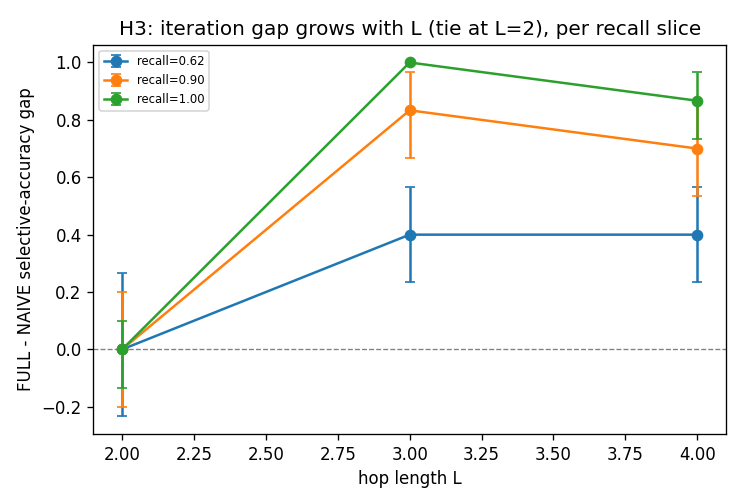

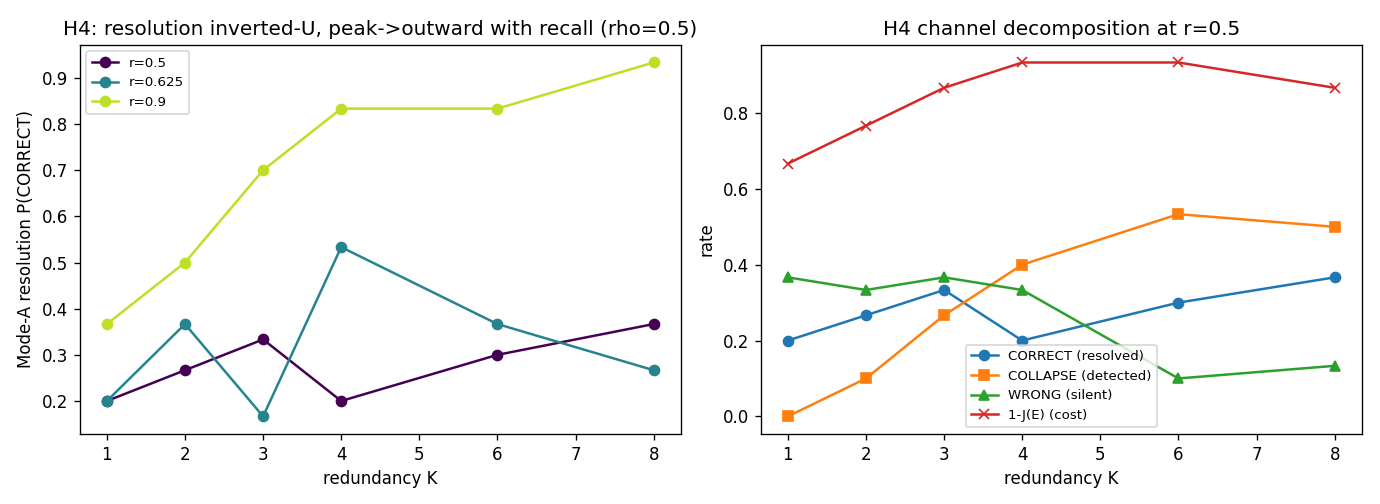

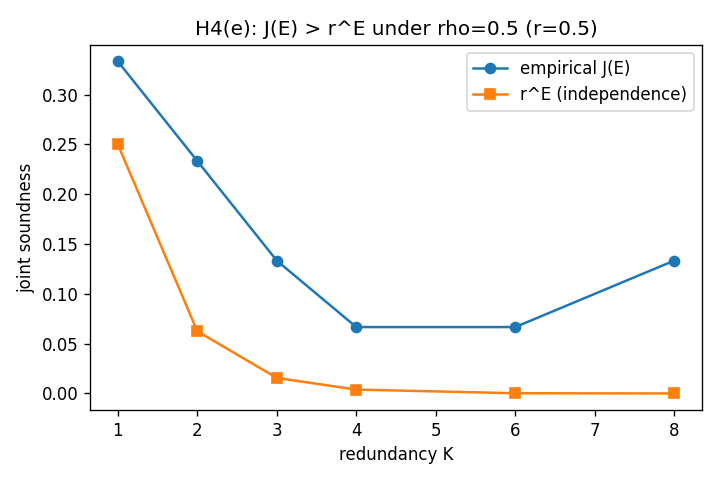

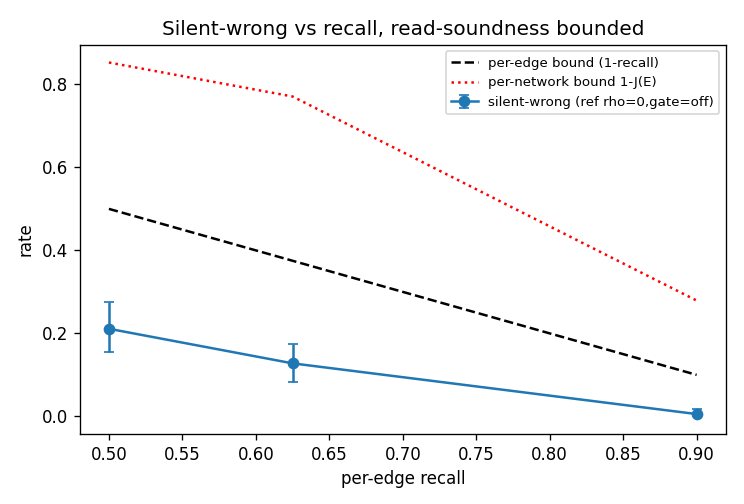

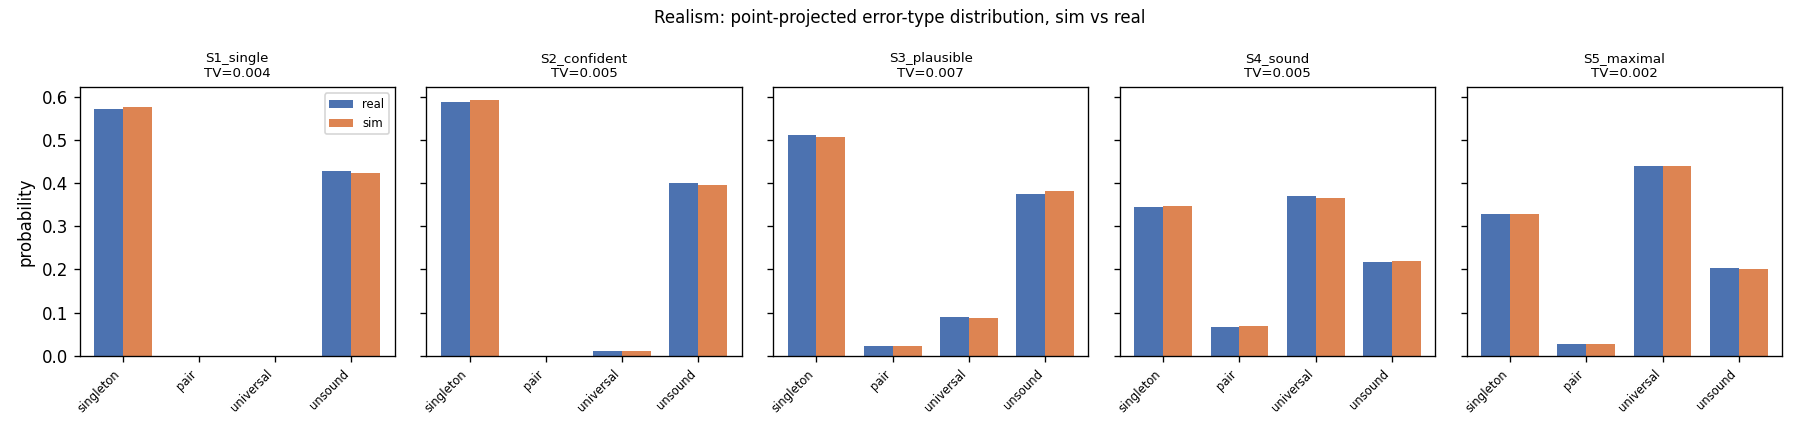

In [27]:
# display the five saved figures inline
for fn in ["fig1_h3_gap_vs_L_per_recall.png", "fig2_h4_inverted_u_decomp.png",
           "fig3_JE_vs_rE.png", "fig4_silent_wrong_vs_recall.png",
           "fig5_realism_error_type_bars.png"]:
    p = FIG_DIR / fn
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print("missing:", fn)